Para fazer uma análise exploratória básica com esses dados, você pode começar com as seguintes etapas:

Verifique a consistência dos dados: Confira se as informações estão completas e coerentes. Verifique se não há valores nulos ou ausentes, se não há informações inconsistentes e se os dados estão em um formato que possa ser facilmente utilizado.

Analise as estatísticas descritivas: Utilize medidas estatísticas como a média, mediana, desvio padrão e quartis para ter uma ideia da distribuição dos dados e identificar possíveis outliers.

Visualize a distribuição dos dados: Utilize gráficos de histogramas, boxplots ou kernel density plots para visualizar a distribuição dos dados e entender melhor como eles estão distribuídos.

Identifique possíveis correlações: Utilize gráficos de dispersão ou coeficientes de correlação para identificar possíveis correlações entre os dados, por exemplo, a relação entre a quantidade de combustível produzido em um estado e a quantidade enviada para outro estado.

Identifique padrões geográficos: Utilize mapas para visualizar onde são produzidos e para onde são enviados os combustíveis. Essa análise pode ajudar a identificar possíveis padrões geográficos e fluxos de distribuição.

Para criar o mapa interativo com os dados por estado listando todos os combustíveis enviados, você pode utilizar ferramentas de visualização de dados como o Tableau ou o PowerBI. Essas ferramentas permitem criar mapas interativos a partir de dados em planilhas.

Para criar o mapa que identifica o maior estado fornecedor por combustível e para onde vai esse combustível, você pode utilizar a biblioteca de visualização de dados em Python, Folium. Essa biblioteca permite criar mapas interativos a partir de dados em DataFrames do Pandas.

Para criar o mapa, você precisará agrupar os dados por estado e combustível e calcular as quantidades de combustível enviado para cada estado. Em seguida, utilize a biblioteca Folium para criar um mapa que mostre o maior estado fornecedor de cada combustível e para onde esse combustível é enviado.

Em resumo, a análise exploratória de dados pode ajudar a identificar padrões e insights importantes sobre a distribuição de combustíveis no Brasil. Utilizando as ferramentas certas, é possível criar visualizações interativas que permitem explorar e entender melhor os dados.

In [16]:
import pandas as pd
import folium
#import great_expectations
from pathlib import Path
from zipfile import ZipFile
import os
from pathlib import Path
from typing import Optional, Sequence
import re
import unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Configuração do Notebook
import warnings
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.options.mode.chained_assignment = None
pd.set_option("display.width", 120)

In [2]:
def check_cols(df, columns=None):
    """
    Returns a summary of column properties: dtype, unique values, number and percentage of NaNs.

    Parameters:
    - df (pd.DataFrame): The dataframe to inspect.
    - columns (list or None): Subset of columns to check. If None, checks all columns.

    Returns:
    - pd.DataFrame: A summary dataframe sorted by the number of NaN values.
    """
    if columns is None:
        columns = df.columns

    nunique_safe = df[columns].apply(lambda col: col.astype(str).nunique())
    dtypes = df[columns].dtypes
    nans = df[columns].isna().sum()
    percent_nans = round((nans / df.shape[0]) * 100, 2)

    df_check = pd.DataFrame({
        'Variável': columns,
        'Tipo': dtypes,
        'Qtde_unicos': nunique_safe,
        'Qtde_NaN': nans,
        '%_NaN': percent_nans
    })

    return df_check.sort_values('Qtde_NaN').reset_index(drop=True)

def remove_accents(a):
    import unidecode
    return unidecode.unidecode(a.encode().decode('utf-8')).upper().strip()

def normalize_col(c):
    c = str(c).strip()
    c = unicodedata.normalize("NFKD", c).encode("ascii", "ignore").decode("ascii")
    c = c.lower()
    c = re.sub(r"[\s\-\/]+", "_", c)
    c = re.sub(r"[^0-9a-z_]", "", c)
    c = re.sub(r"_+", "_", c).strip("_")
    return c

def extract_all_zips(folder, recursive=True, delete_zip=False):
    """
    Descompacta todos os .zip da pasta (e subpastas se recursive=True).
    Extrai no próprio 'folder'. Opcionalmente remove os .zip após extrair.
    Retorna uma lista de arquivos extraídos.
    """
    base = Path(folder).resolve()
    pattern = "**/*.zip" if recursive else "*.zip"
    extracted = []

    for zpath in sorted(base.glob(pattern)):
        with ZipFile(zpath) as zf:
            # segurança: evita path traversal
            for m in zf.infolist():
                target = (base / m.filename).resolve()
                if not str(target).startswith(str(base)):
                    raise RuntimeError(f"Entrada suspeita no ZIP: {m.filename}")
            zf.extractall(path=base)
            extracted.extend([str((base / m.filename).resolve()) for m in zf.infolist() if m.filename.lower().endswith(".csv")])
        if delete_zip:
            zpath.unlink()
    return extracted

def concatenar_csvs_da_pasta(caminho_da_pasta, nome_arquivo_saida, separador=';', encodings_a_tentar=['utf-8-sig', 'latin1', 'iso-8859-1']):
    """
    Tenta concatenar todos os arquivos CSV de uma pasta, lidando com diferentes
    codificações e erros de formatação nas linhas.

    Args:
        caminho_da_pasta (str): O caminho do diretório contendo os arquivos CSV.
        nome_arquivo_saida (str): O nome do arquivo CSV de saída para salvar o resultado.
        separador (str): O caractere separador dos campos (ponto e vírgula, vírgula, etc.).
        encodings_a_tentar (list): Lista de codificações a serem tentadas.

    Returns:
        pd.DataFrame: O DataFrame pandas resultante da concatenação.
    """
    # Lista para armazenar os DataFrames de cada arquivo CSV
    lista_dataframes = []
    arquivos_com_erro = []

    # Itera sobre todos os arquivos no diretório
    for arquivo in os.listdir(caminho_da_pasta):
        # Verifica se o arquivo é um CSV
        if arquivo.endswith('.csv'):
            caminho_completo_arquivo = os.path.join(caminho_da_pasta, arquivo)
            print(f'Lendo o arquivo: {caminho_completo_arquivo}')
            
            df_temporario = None
            leitura_bem_sucedida = False
            
            # Tenta ler o arquivo com diferentes codificações
            for encoding in encodings_a_tentar:
                try:
                    df_temporario = pd.read_csv(
                        caminho_completo_arquivo,
                        encoding=encoding,
                        sep=separador,
                        on_bad_lines='skip', # Ignora linhas com erros de formatação
                        low_memory=False # Ajuda a evitar erros de tipo em datasets grandes
                    )
                    lista_dataframes.append(df_temporario)
                    print(f"Sucesso com o separador '{separador}' e codificação '{encoding}'.")
                    leitura_bem_sucedida = True
                    break # Sai do loop de encodings se a leitura foi bem-sucedida
                except Exception as e:
                    continue # Tenta a próxima codificação se houver um erro

            if not leitura_bem_sucedida:
                print(f"Falha ao ler o arquivo {arquivo} com os parâmetros fornecidos.")
                arquivos_com_erro.append(arquivo)
                
    # Verifica se a lista de DataFrames não está vazia
    if not lista_dataframes:
        print("Nenhum arquivo CSV pôde ser lido na pasta.")
        return pd.DataFrame()

    # Concatena todos os DataFrames da lista em um único DataFrame
    df_final = pd.concat(lista_dataframes, ignore_index=True)
    print(f'\nConcluído! {len(lista_dataframes)} arquivos foram lidos e concatenados.')
    print(f'O DataFrame final tem {len(df_final)} linhas.')
    
    if arquivos_com_erro:
        print(f"Os seguintes arquivos não puderam ser lidos: {', '.join(arquivos_com_erro)}")

    # Salva o DataFrame final em um novo arquivo CSV
    df_final.to_csv(nome_arquivo_saida, index=False)
    print(f'O DataFrame concatenado foi salvo em: {nome_arquivo_saida}')

    return df_final



# Função para criar e salvar gráficos de barras
def plot_bar_chart(df, group_col, value_col, title, filename):
    import seaborn as sns
    plt.figure(figsize=(12, 8))
    # Agrupar e somar os valores para plotagem
    grouped_data = df.groupby(group_col)[value_col].sum().sort_values(ascending=False)
    sns.barplot(x=grouped_data.index, y=grouped_data.values, palette='viridis')
    plt.title(title)
    plt.xlabel(group_col)
    plt.ylabel(f'Soma do {value_col}')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(filename)
    plt.close()

Dados:  </br>
https://www.gov.br/anp/pt-br/assuntos/precos-e-defesa-da-concorrencia/precos/levantamento-de-precos-de-combustiveis-ultimas-semanas-pesquisadas </br>
-> serie historica https://www.gov.br/anp/pt-br/centrais-de-conteudo/dados-abertos/serie-historica-de-precos-de-combustiveis

In [3]:
pasta = "/home/wsl/tcc/dados_tcc_precos"

# # 1) Descompactar todos os .zip
# extraidos = extract_all_zips(pasta, recursive=False, delete_zip=False)
# print("CSV extraídos:", len(extraidos))

In [4]:
# # Define o nome do arquivo de saída
# arquivo_final_csv = 'dados_completos_combustiveis.csv'

# # Chama a função para concatenar os arquivos
# df_completo = concatenar_csvs_da_pasta(pasta, arquivo_final_csv)

# # Exibe as primeiras linhas do DataFrame final para verificação
# print("\nDataFrame final (primeiras 5 linhas):")
# print(df_completo.head())

#df_completo.to_csv('lubricants_anp_full.csv', sep=';') 


In [21]:
df_raw = pd.read_csv('lubricants_anp_full.csv', sep=';') 
df_raw.head(1)

,Unnamed: 0,Regiao - Sigla,Estado - Sigla,Municipio,Revenda,CNPJ da Revenda,Nome da Rua,Numero Rua,Complemento,Bairro,Cep,Produto,Data da Coleta,Valor de Venda,Valor de Compra,Unidade de Medida,Bandeira
0,0,SE,SP,SOROCABA,COMPETRO COMERCIO E DISTRIBUICAO DE DERIVADOS ...,00.003.188/0001-21,RUA HUMBERTO DE CAMPOS,306,NaN,JARDIM ZULMIRA,18061-000,GASOLINA,03/07/2023,"4,87",NaN,R$ / litro,BRANCA


In [22]:
df = df_raw.copy()

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7422035 entries, 0 to 7422034
Data columns (total 17 columns):
 #   Column             Dtype 
---  ------             ----- 
 0   Unnamed: 0         int64 
 1   Regiao - Sigla     object
 2   Estado - Sigla     object
 3   Municipio          object
 4   Revenda            object
 5   CNPJ da Revenda    object
 6   Nome da Rua        object
 7   Numero Rua         object
 8   Complemento        object
 9   Bairro             object
 10  Cep                object
 11  Produto            object
 12  Data da Coleta     object
 13  Valor de Venda     object
 14  Valor de Compra    object
 15  Unidade de Medida  object
 16  Bandeira           object
dtypes: int64(1), object(16)
memory usage: 962.6+ MB


In [26]:
df.sample(1)

,Unnamed: 0,Regiao - Sigla,Estado - Sigla,Municipio,Revenda,CNPJ da Revenda,Nome da Rua,Numero Rua,Complemento,Bairro,Cep,Produto,Data da Coleta,Valor de Venda,Valor de Compra,Unidade de Medida,Bandeira
5099031,5099031,SE,MG,BELO HORIZONTE,POSTO DE ABASTECIMENTO JATOBA LTDA,18.468.690/0001-73,AVENIDA SENADOR LEVINDO COELHO,1800,NaN,CDI JATOBA (BARREIRO),30664-006,GASOLINA,01/04/2019,"4,499",NaN,R$ / litro,PETROBRAS DISTRIBUIDORA S.A.


In [6]:
check_cols(df, df.columns)

,Variável,Tipo,Qtde_unicos,Qtde_NaN,%_NaN
0,Unnamed: 0,int64,7422035,0,0.00
1,Regiao - Sigla,object,6,9114,0.12
2,Estado - Sigla,object,28,9114,0.12
3,Municipio,object,528,9114,0.12
4,Revenda,object,21642,9114,0.12
5,CNPJ da Revenda,object,23853,9114,0.12
6,Nome da Rua,object,13761,9114,0.12
7,Produto,object,7,9114,0.12
8,Unidade de Medida,object,3,9114,0.12
9,Cep,object,15864,9114,0.12


In [27]:
# clean
df = df.drop(columns='Unnamed: 0')
df['Valor de Venda'] = df['Valor de Venda'].str.replace(',', '.', regex=True).astype(float)
df['Data da Coleta'] = pd.to_datetime(df['Data da Coleta'], format='%d/%m/%Y')
df['Ano'] = df['Data da Coleta'].dt.year

Graficos salvos na pasta.

In [8]:
# # 1. Gráfico de Valor de Venda por Região
# plot_bar_chart(df, 'Regiao - Sigla', 'Valor de Venda', 'Valor de Venda por Região', 'valor_venda_por_regiao.png')

# # 2. Gráfico de Valor de Venda por Estado
# plot_bar_chart(df, 'Estado - Sigla', 'Valor de Venda', 'Valor de Venda por Estado', 'valor_venda_por_estado.png')

# # 3. Gráfico de Valor de Venda por Município
# # Considerando que pode haver muitos municípios, vamos pegar os top 10 para visualização
# top_10_municipios = df['Municipio'].value_counts().nlargest(10).index
# df_top_municipios = df[df['Municipio'].isin(top_10_municipios)]
# plot_bar_chart(df_top_municipios, 'Municipio', 'Valor de Venda', 'Top 10 Municípios por Valor de Venda', 'valor_venda_por_municipio.png')

# # 4. Gráfico de Valor de Venda por Bairro dentro de um Estado
# # Escolhendo o estado com mais ocorrências para a análise por bairro.
# most_frequent_state = df['Estado - Sigla'].mode()[0]
# df_state = df[df['Estado - Sigla'] == most_frequent_state]

# # Pegando os top 10 bairros dentro do estado
# top_10_bairros = df_state['Bairro'].value_counts().nlargest(10).index
# df_bairro = df_state[df_state['Bairro'].isin(top_10_bairros)]
# plot_bar_chart(df_bairro, 'Bairro', 'Valor de Venda', f'Top 10 Bairros em {most_frequent_state} por Valor de Venda', 'valor_venda_por_bairro.png')

# # 5. Gráfico de Valor de Venda por Distribuidora (Bandeira)
# # Pegando as top 10 bandeiras
# top_10_bandeiras = df['Bandeira'].value_counts().nlargest(10).index
# df_bandeiras = df[df['Bandeira'].isin(top_10_bandeiras)]
# plot_bar_chart(df_bandeiras, 'Bandeira', 'Valor de Venda', 'Top 10 Bandeiras por Valor de Venda', 'valor_venda_por_bandeira.png')

# # 6. Gráfico de Valor de Venda por Ano
# plot_bar_chart(df, 'Ano', 'Valor de Venda', 'Valor de Venda por Ano', 'valor_venda_por_ano.png')

Bloco de análise

In [28]:
df.head(1)

,Regiao - Sigla,Estado - Sigla,Municipio,Revenda,CNPJ da Revenda,Nome da Rua,Numero Rua,Complemento,Bairro,Cep,Produto,Data da Coleta,Valor de Venda,Valor de Compra,Unidade de Medida,Bandeira,Ano
0,SE,SP,SOROCABA,COMPETRO COMERCIO E DISTRIBUICAO DE DERIVADOS ...,00.003.188/0001-21,RUA HUMBERTO DE CAMPOS,306,NaN,JARDIM ZULMIRA,18061-000,GASOLINA,2023-07-03,4.87,NaN,R$ / litro,BRANCA,2023.0


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7422035 entries, 0 to 7422034
Data columns (total 17 columns):
 #   Column             Dtype         
---  ------             -----         
 0   Regiao - Sigla     object        
 1   Estado - Sigla     object        
 2   Municipio          object        
 3   Revenda            object        
 4   CNPJ da Revenda    object        
 5   Nome da Rua        object        
 6   Numero Rua         object        
 7   Complemento        object        
 8   Bairro             object        
 9   Cep                object        
 10  Produto            object        
 11  Data da Coleta     datetime64[ns]
 12  Valor de Venda     float64       
 13  Valor de Compra    object        
 14  Unidade de Medida  object        
 15  Bandeira           object        
 16  Ano                float64       
dtypes: datetime64[ns](1), float64(2), object(14)
memory usage: 962.6+ MB


In [30]:
df.columns = [normalize_col(c) for c in df.columns]

In [31]:
# Renomeios suaves para padronizar
rename_map = {
    "cnpj_da_revenda": "cnpj_revenda",
    "nome_da_rua": "rua",
    "numero_rua": "numero_rua",
    "data_da_coleta": "data_coleta",
    "valor_de_venda": "valor_venda",
    "valor_de_compra": "valor_compra",
    "unidade_de_medida": "unidade_medida",
    "regiao__sigla": "regiao_sigla",
    "regiao_sigla": "regiao_sigla",
    "estado__sigla": "estado_sigla",
    "estado_sigla": "estado_sigla",
}
df = df.rename(columns=rename_map)

In [32]:
# Valor de venda (garantir numérico mesmo se veio com símbolos)
if "valor_venda" in df.columns:
    # Remove "R$" e espaços se existirem
    df["valor_venda"] = (
        df["valor_venda"]
        .astype(str)
        .str.replace("R$", "", regex=False)
        .str.replace(" ", "", regex=False)
    )
    # Se o decimal for vírgula, converte para ponto
    df["valor_venda"] = pd.to_numeric(df["valor_venda"], errors="coerce")

# Ano: remover ".0" -> inteiro (Int64 para permitir NA)
if "ano" in df.columns:
    df["ano"] = pd.to_numeric(df["ano"], errors="coerce").astype("Int64")
else:
    # Se não existir, inferir de data_coleta (se disponível)
    if "data_coleta" in df.columns:
        df["ano"] = df["data_coleta"].dt.year.astype("Int64")

# Preencher anos ausentes com o ano da data_coleta (se possível)
if "ano" in df.columns and "data_coleta" in df.columns:
    ano_inferido = df["data_coleta"].dt.year.astype("Int64")
    df["ano"] = df["ano"].fillna(ano_inferido)

# Ignorar Valor de Compra (remover da análise atual)
if "valor_compra" in df.columns:
    df = df.drop(columns=["valor_compra"])

# Remover linhas sem valor de venda
if "valor_venda" in df.columns:
    df = df[~df["valor_venda"].isna()].copy()

# Limpar espaços em textos-chave
for col in ["regiao_sigla", "estado_sigla", "municipio", "produto", "bandeira", "bairro"]:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()

# Limpar colunas com muitos valores vazios (numero da rua e complemento)
df = df.drop(columns=["complemento", "numero_rua"])

In [33]:
check_cols(df, df.columns)

,Variável,Tipo,Qtde_unicos,Qtde_NaN,%_NaN
0,regiao_sigla,object,5,0,0.0
1,estado_sigla,object,27,0,0.0
2,municipio,object,527,0,0.0
3,revenda,object,21641,0,0.0
4,cnpj_revenda,object,23852,0,0.0
5,rua,object,13760,0,0.0
6,bairro,object,8344,0,0.0
7,cep,object,15863,0,0.0
8,produto,object,6,0,0.0
9,data_coleta,datetime64[ns],2024,0,0.0


In [34]:
#valores ausentes
print("Formato (linhas, colunas):", df.shape)
print("\nColunas:", list(df.columns))
print("\nPercentual de valores ausentes por coluna:")
print((df.isna().mean()*100).round(2).sort_values(ascending=False))

Formato (linhas, colunas): (7412921, 14)

Colunas: ['regiao_sigla', 'estado_sigla', 'municipio', 'revenda', 'cnpj_revenda', 'rua', 'bairro', 'cep', 'produto', 'data_coleta', 'valor_venda', 'unidade_medida', 'bandeira', 'ano']

Percentual de valores ausentes por coluna:
regiao_sigla      0.0
estado_sigla      0.0
municipio         0.0
revenda           0.0
cnpj_revenda      0.0
rua               0.0
bairro            0.0
cep               0.0
produto           0.0
data_coleta       0.0
valor_venda       0.0
unidade_medida    0.0
bandeira          0.0
ano               0.0
dtype: float64



Preço de venda por Região (count, mean, median, std):


,count,mean,median,std
regiao_sigla,,,,
N,462922,5.131654,4.890,1.323826
NE,1465867,4.779390,4.590,1.276205
S,1243617,4.746758,4.589,1.292858
CO,643294,4.594737,4.300,1.304823
SE,3597221,4.541628,4.299,1.314172



Ano x Valor de Venda:


,count,mean,median,std
ano,,,,
2022,907502,6.117853,6.290,1.136970
2025,420409,5.890884,6.170,0.893260
2024,898536,5.558804,5.860,0.918802
2023,904000,5.302210,5.490,0.877348
2021,807537,5.237572,5.199,0.926472
2019,1004029,3.748456,3.699,0.597086
2018,963002,3.702545,3.599,0.628194
2020,719300,3.654332,3.609,0.624924
2017,788606,3.263891,3.210,0.479330



Produto x Valor de Venda:


...

bandeira,76 OIL,ACOL,AIR BP,ALE,ALE COMBUSTÍVEIS,ALESAT,AMAZONGÁS,AMERICANOIL,ATEM' S,ATLÂNTICA,BAHIANA,BRANCA,BREMEN,CBPI,CHARRUA,CIAPETRO,DIBRAPE,DINAMO,DISLUB,D`MAIS,ELLO,EQUADOR,ESTRADA,FAN,FEDERAL,FEDERAL ENERGIA,FOGAS,GP,GRAN PETRO,HORA,IDAZA,IPIRANGA,LARCO,LIQUIGÁS,MASUT DISTRIBUIDORA,MAXSUL,MEGAPETRO,MERCOIL,MONTEPETRO,NACIONAL GÁS BUTANO,ON PETRO,PDV BRASIL,PELIKANO,PETROBAHIA,PETROBRAS DISTRIBUIDORA S.A.,PETROBRASIL,PETROLUZ,PETRONAC,PETROSERRA,PETROX,PETROX DISTRIBUIDORA,PODIUM,POLIPETRO,POTENCIAL,PR DISTRIBUIDORA,RAIZEN,RAIZEN MIME,RDP ENERGIA,REDE SOL,REJAILE,RIO BRANCO,RM PETROLEO,RODOIL,ROYAL FIC,RUFF C.J.,RUMOS,RZD DISTRIBUIDORA,SAARA,SABBÁ,SANTA LUCIA,SATELITE,SETTA DISTRIBUIDORA,SIM DISTRIBUIDOR,SIMARELLI,SMALL,SOLL,SP,STANG,SUL COMBUSTÍVEIS,SULPETRO,SUPERGASBRAS ENERGIA,TAG DISTRIBUIDORA,TAURUS,TDC DISTRIBUIDORA,TEMAPE,TOBRAS,TORRAO,TOTAL BRASIL,TOTALENERGIES,ULTRAGAZ,UNI,VIBRA,VIBRA ENERGIA,WALENDOWSKY,WATT,ZEMA
produto,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
DIESEL,3.599,3.420426,5.658421,6.028492,3.206190,4.440033,7.390000,4.655147,4.750720,4.136086,NaN,4.444078,NaN,3.079477,4.774377,4.206589,4.566923,NaN,4.690691,4.066976,NaN,4.906490,5.070212,4.358044,3.450792,5.783511,6.776000,3.250743,3.251889,3.449989,4.696864,4.628434,5.359020,6.380000,4.820294,5.006648,3.296653,NaN,4.385525,NaN,5.815000,NaN,4.237842,4.288534,3.476230,5.966000,3.567124,2.966778,3.783164,3.159857,4.597998,3.601108,3.599000,4.791659,NaN,4.439405,4.227257,NaN,NaN,3.472775,4.286885,3.071442,4.852042,5.376744,3.350853,NaN,4.522091,2.997868,4.817881,6.267874,3.189147,4.515669,5.94125,4.319911,4.312526,3.152500,4.193319,4.408468,4.987717,2.710174,6.570000,3.995000,4.843061,3.568463,5.011162,3.432384,3.577886,3.929646,6.087505,6.626667,2.932424,6.109793,5.869876,5.467192,4.538806,3.413466
DIESEL S10,NaN,3.524203,5.667500,6.138259,3.314648,4.695210,7.356667,4.263501,5.054909,4.689375,7.390,4.712116,3.399,3.183049,4.889528,4.418013,4.522902,NaN,4.589166,4.312337,2.999,5.119812,5.137452,4.639414,3.201585,5.692636,6.792222,3.308114,3.307333,3.244000,4.564119,4.728710,5.422079,5.668880,5.007478,5.110479,3.476651,NaN,4.470079,6.783333,5.878152,3.138545,4.293183,4.716418,3.585634,5.588636,3.632141,3.168370,3.874315,3.268837,4.645522,3.820156,3.232765,4.975365,3.899,4.563861,4.321810,NaN,3.282333,3.615496,4.590770,3.111012,5.071962,4.370034,3.838007,NaN,4.792378,3.163083,4.693351,6.374151,3.336845,4.320398,6.00375,4.659090,4.210742,3.299167,4.533138,4.519146,5.116988,2.821609,6.490000,3.695000,4.843813,4.032809,5.168190,3.705460,3.865736,4.181770,6.077030,6.112000,3.925227,6.175423,5.952127,5.383521,4.442604,3.507163
ETANOL,3.599,2.924324,4.712500,4.392821,2.997718,3.730887,4.223333,3.983160,4.117108,4.084178,4.465,3.651581,2.599,2.963882,4.502036,3.400803,3.928432,NaN,4.125238,2.988555,2.969,4.325715,3.741079,4.017907,3.073566,4.621139,3.990000,2.995771,2.567750,3.319032,3.353311,3.743836,4.226752,3.698129,3.587281,4.358298,3.967679,2.199,3.565269,4.260000,4.357520,3.305250,3.471907,4.030153,3.217506,3.591304,2.611880,2.748370,3.595809,3.273108,4.138602,2.687883,3.386444,3.836943,3.189,3.702643,4.237320,NaN,2.540667,3.469919,3.539413,2.552843,4.149568,3.480066,2.922950,2.269,4.473651,3.449973,4.338111,4.844797,3.287324,3.873563,4.00375,3.528533,3.760231,3.292800,4.108820,3.850350,4.249087,NaN,4.267000,3.415000,3.759136,3.726336,4.383459,3.434125,3.083734,3.772896,4.238240,3.965714,3.564056,4.274266,4.827862,4.657407,3.287432,2.969650
GASOLINA,4.699,4.335192,5.854500,6.142229,3.938582,5.015351,5.280000,4.749420,5.295862,4.990202,4.665,5.052997,3.999,3.757149,5.271694,4.894424,5.008207,NaN,5.173787,4.434912,3.620,5.435072,5.436337,5.096675,3.945286,6.011849,5.207778,4.310143,4.084625,4.402305,4.844075,5.116085,5.582822,4.632947,5.251806,5.384574,4.455310,3.279,5.149379,4.724000,6.174560,3.635957,4.772177,5.199300,4.323797,4.980204,4.212406,3.644457,4.636364,3.946884,5.215785,4.317772,4.107579,5


Preço médio (R$) por Bandeira x Ano x Produto:


bandeira                 76 OIL      ACOL    AIR BP      ALE  ALE COMBUSTÍVEIS    ALESAT  AMAZONGÁS  AMERICANOIL  \
ano  produto                                                                                                       
2017 DIESEL                 NaN  3.140308       NaN      NaN          3.096919  3.112576        NaN          NaN   
     DIESEL S10             NaN  3.285440       NaN      NaN          3.201598  3.224092        NaN     3.052809   
     ETANOL                 NaN  2.757008       NaN      NaN          2.893365  2.960265        NaN     3.427794   
     GASOLINA               NaN  3.885087       NaN      NaN          3.725705  3.805085        NaN     3.597162   
     GNV                    NaN       NaN       NaN      NaN          2.154743  2.326665        NaN     2.938261   
2018 DIESEL                 NaN  3.582418       NaN      NaN          3.444904  3.536070        NaN     3.276750   
     DIESEL S10             NaN  3.702891       NaN      NaN          3.523927  3.608628        NaN     3.368122   
     ETANOL                 NaN  3.089700       NaN      NaN          3.211765  3.224303        NaN     3.531557   
     GASOLINA               NaN  4.762967       NaN      NaN          4.321838  4.490534        NaN     4.149240   
     GNV                    NaN       NaN       NaN      NaN          2.471688  2.785532        NaN     3.015731   
2019 DIESEL               3.599  3.604824       NaN      NaN               NaN  3.624106        NaN     3.381153   
     DIESEL S10             NaN  3.672417  3.550000      NaN               NaN  3.704064        NaN     3.470211   
     ETANOL               3.599  3.063000  3.150000      NaN               NaN  3.280275        NaN     3.394603   
     GASOLINA             4.699  4.758368  4.450000      NaN               NaN  4.503567        NaN     4.121585   
     GNV                    NaN       NaN       NaN      NaN               NaN  3.302833        NaN     3.171000   
2020 DIESEL                 NaN  3.451481       NaN      NaN               NaN  3.440985        NaN     3.228413   
     DIESEL S10             NaN  3.578000       NaN      NaN               NaN  3.522991        NaN     3.294696   
     ETANOL                 NaN  2.958704       NaN      NaN               NaN  3.258726        NaN     3.593891   
     GASOLINA               NaN  4.414185       NaN      NaN               NaN  4.350062        NaN     4.193368   
     GASOLINA ADITIVADA     NaN       NaN       NaN      NaN               NaN  4.627581        NaN     4.451000   
     GNV                    NaN       NaN       NaN      NaN               NaN  3.203645        NaN     2.949000   
2021 DIESEL                 NaN       NaN       NaN      NaN               NaN  4.728078        NaN     4.502269   
     DIESEL S10             NaN       NaN       NaN      NaN               NaN  4.777120        NaN     4.486397   
     ETANOL                 NaN       NaN       NaN      NaN               NaN  4.803120        NaN     4.985292   
     GASOLINA               NaN       NaN       NaN      NaN               NaN  6.004958        NaN     5.708627   
     GASOLINA ADITIVADA     NaN       NaN       NaN      NaN               NaN  6.074850        NaN     5.796780   
     GNV                    NaN       NaN       NaN      NaN               NaN  3.946558        NaN     3.754952   
2022 DIESEL                 NaN       NaN       NaN      NaN               NaN  6.644896   7.390000     6.394957   
     DIESEL S10             NaN       NaN       NaN      NaN               NaN  6.775541   7.356667     6.506583   
     ETANOL                 NaN       NaN       NaN      NaN               NaN  4.852495   4.223333     5.878571   
     GASOLINA               NaN       NaN       NaN      NaN               NaN  6.293082   5.280000     6.491321   
     GASOLINA ADITIVADA     NaN       NaN       NaN      NaN               NaN  6.425745   5.320000     6.689612   
     GNV                    NaN       NaN       NaN     


Preço médio (R$) por Produto x Bairro:


valor_venda
produto            bairro                                                        
GASOLINA ADITIVADA ALPHAVILLE CENTRO INDUSTRIAL E EMPRESARIAL/ALPHAV     8.990000
DIESEL S10         ALPHAVILLE CENTRO INDUSTRIAL E EMPRESARIAL/ALPHAV     8.990000
GASOLINA           ALPHAVILLE CENTRO INDUSTRIAL E EMPRESARIAL/ALPHAV     8.890000
GASOLINA ADITIVADA JARDIM ITAQUI                                         8.764545
DIESEL S10         JD PAULISTA                                           8.477395
GASOLINA ADITIVADA VL CLEMENTINO                                         8.368483
                   ENTRONCAMENTO DE JAGUAQUARA                           8.258500
                   EMILIO MOREIRA                                        8.247500
DIESEL S10         JAUARY                                                8.150000
GASOLINA           EMILIO MOREIRA                                        8.139118
DIESEL S10         EMILIO MOREIRA                                        8.096250
GASOLINA ADITIVADA PAULO CORREA                                          8.039556
                   ALPHAVILLE CONDE I                                    7.999935
                   VILA RIBEIRO                                          7.990000
                   NOVA LONDRINA                                         7.990000
GNV                JARDIM FLORIANOPOLIS                                  7.990000
GASOLINA ADITIVADA IPÊ AMARELO                                           7.990000
DIESEL             GONZAGA                                               7.990000
                   ERMITAGE                                              7.990000
GASOLINA ADITIVADA LUXEMBURGO                                            7.945000
                   JOAO RIBEIRO                                          7.912368
DIESEL S10         PACAS                                                 7.892000
                   NOVA LONDRINA                                         7.890000
DIESEL             PACAS                                                 7.874000
DIESEL S10         JARDIM FLORIANOPOLIS                                  7.870000
GASOLINA           JACAREACANGA                                          7.846667
GASOLINA ADITIVADA MAJOR LAGE                                            7.832500
DIESEL S10         BAIRRO DO GINASIO                                     7.832222
GASOLINA           PARQUE CAMPO BELO - JAPUÍBA                           7.830872
GASOLINA ADITIVADA CIDADE SANTA MARIA                                    7.830000
                   MANOA                                                 7.810000
                   PLANALTO PAULISTA                                     7.795085
GNV                CONDOMINIO FLORAIS CUIABA                             7.790000
GASOLINA ADITIVADA VILA CATIBOABA                                        7.780000
DIESEL             CENTRO SEDE                                           7.770000
GASOLINA ADITIVADA SETOR NW1                                             7.760000
DIESEL S10         LOT. MANOEL COTRIM                                    7.740000
GASOLINA ADITIVADA BAIRRO HELENA                                         7.732800
DIESEL S10         SANTA TECLA                                           7.702500
GASOLINA ADITIVADA ALTO DE PINHEIROS                                     7.697723

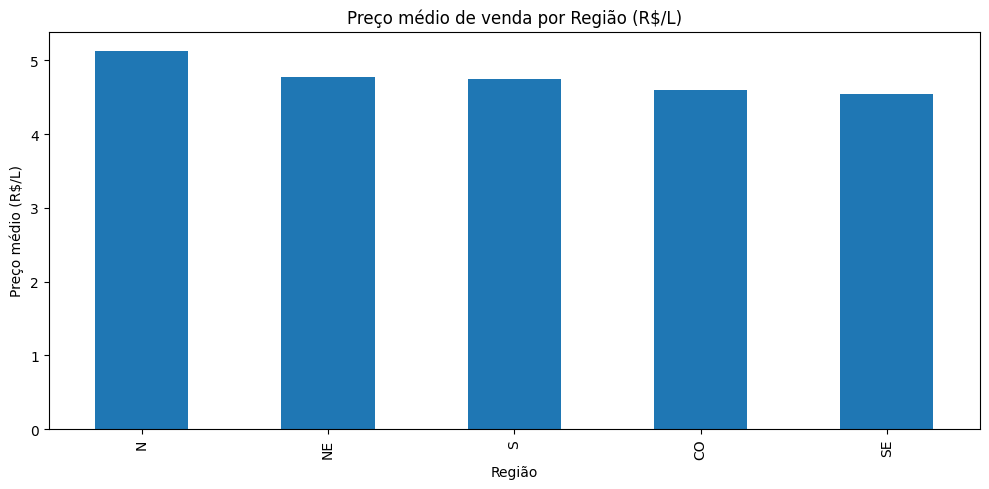

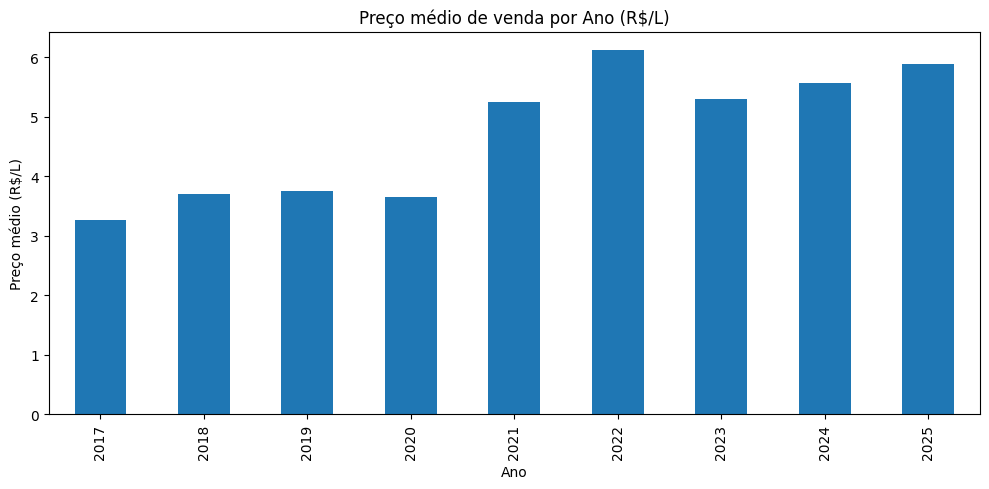

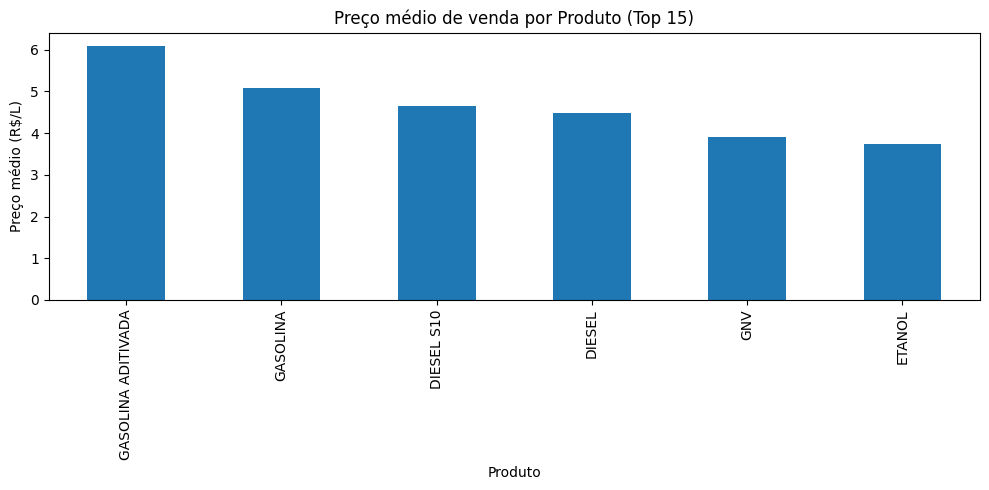

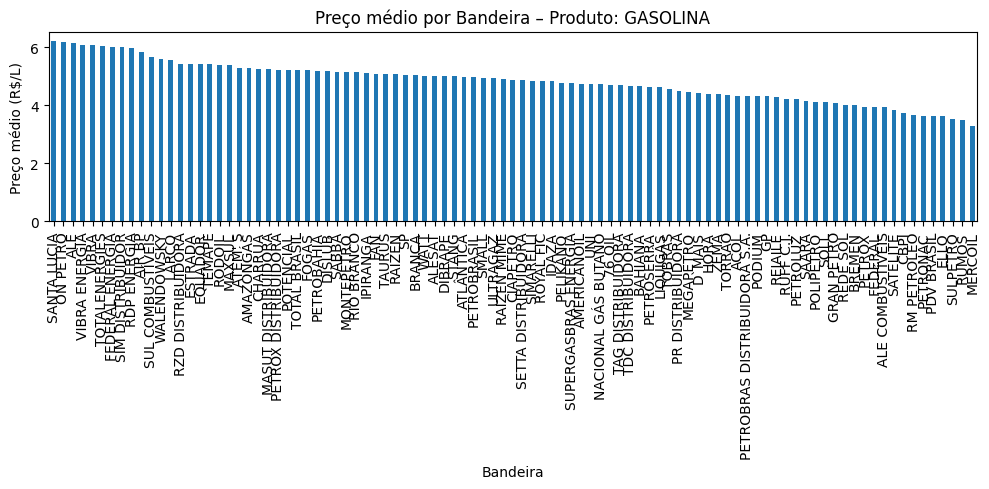

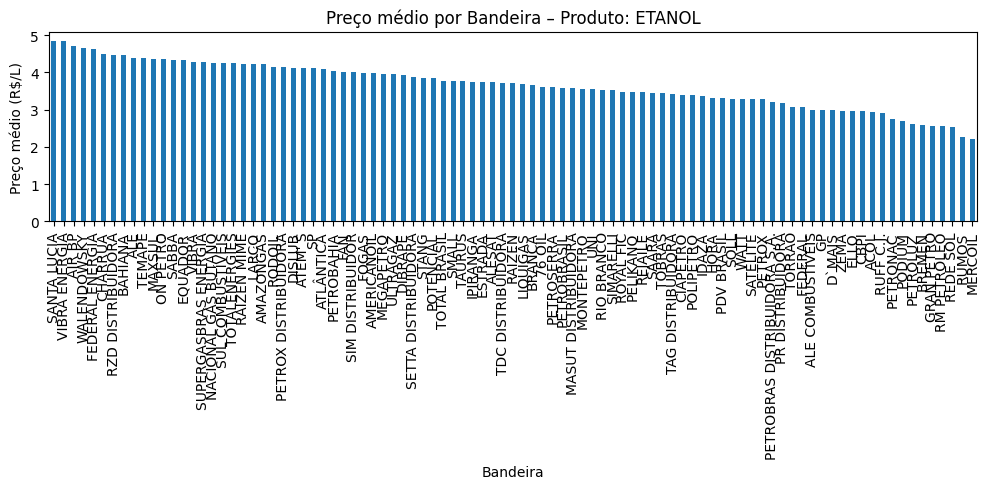

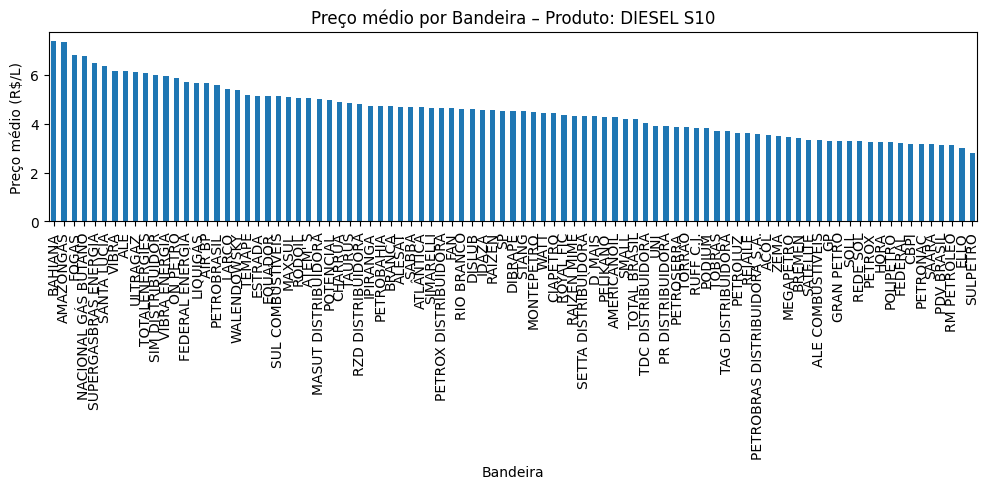

<Figure size 1000x500 with 0 Axes>

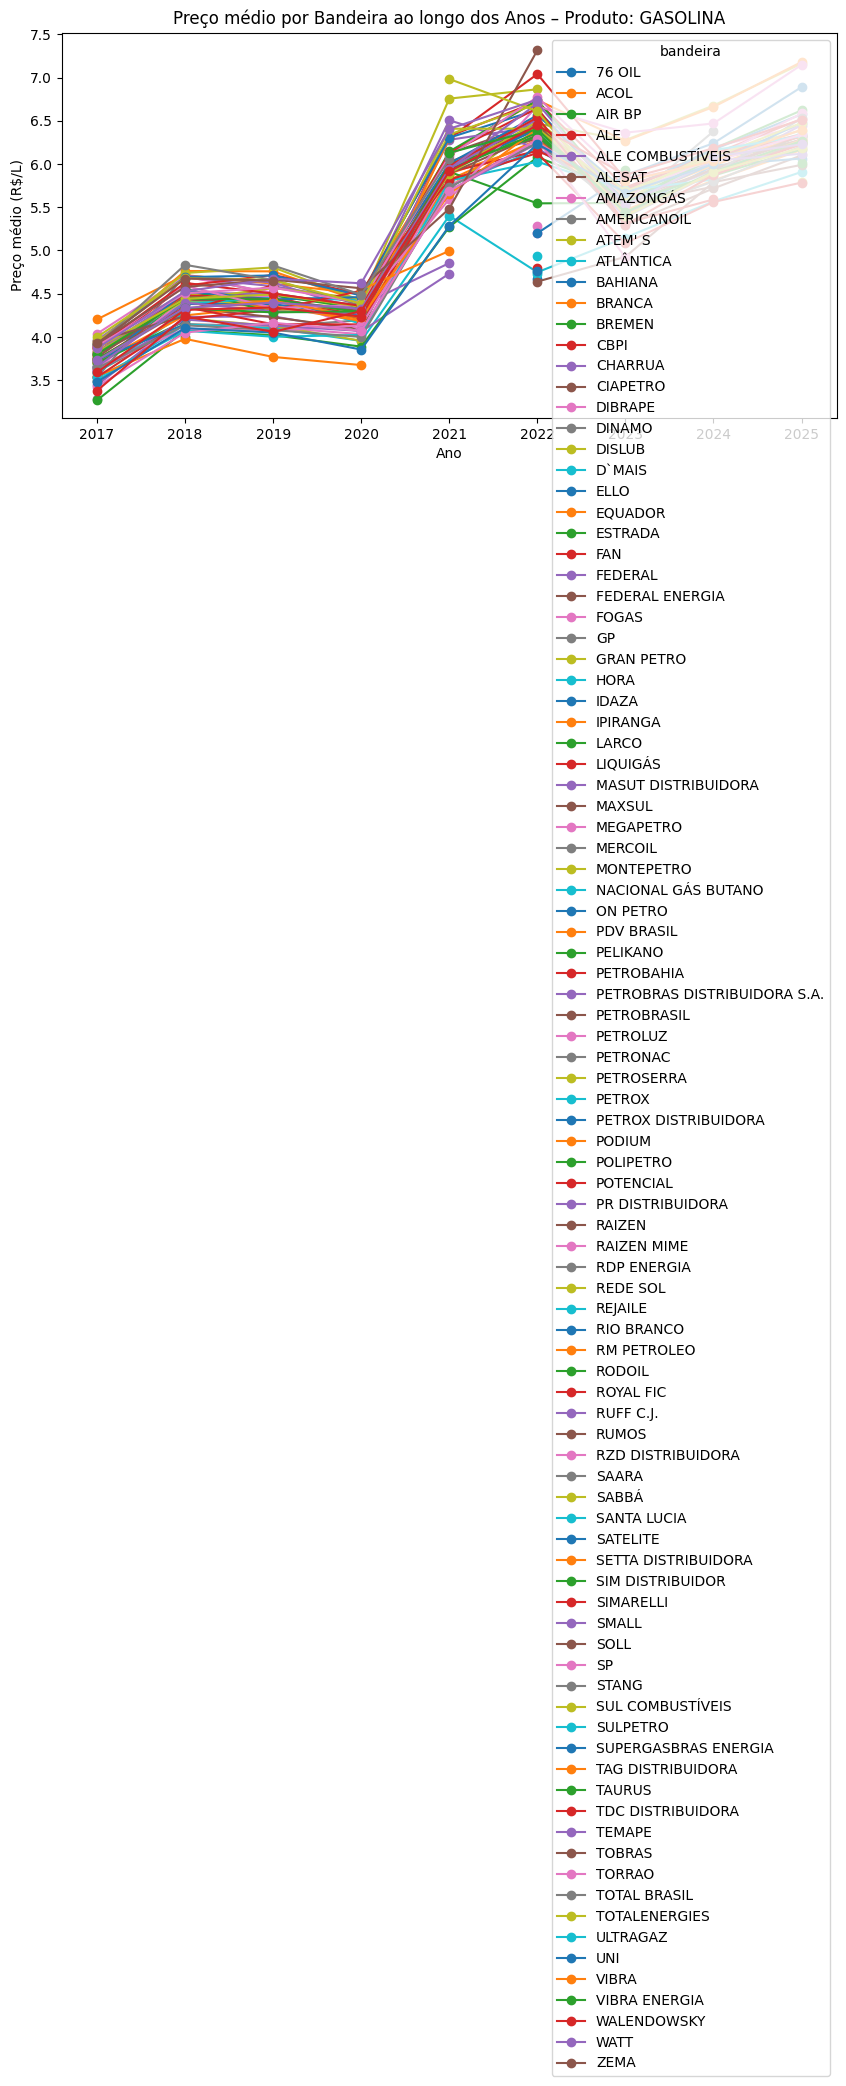

<Figure size 1000x500 with 0 Axes>

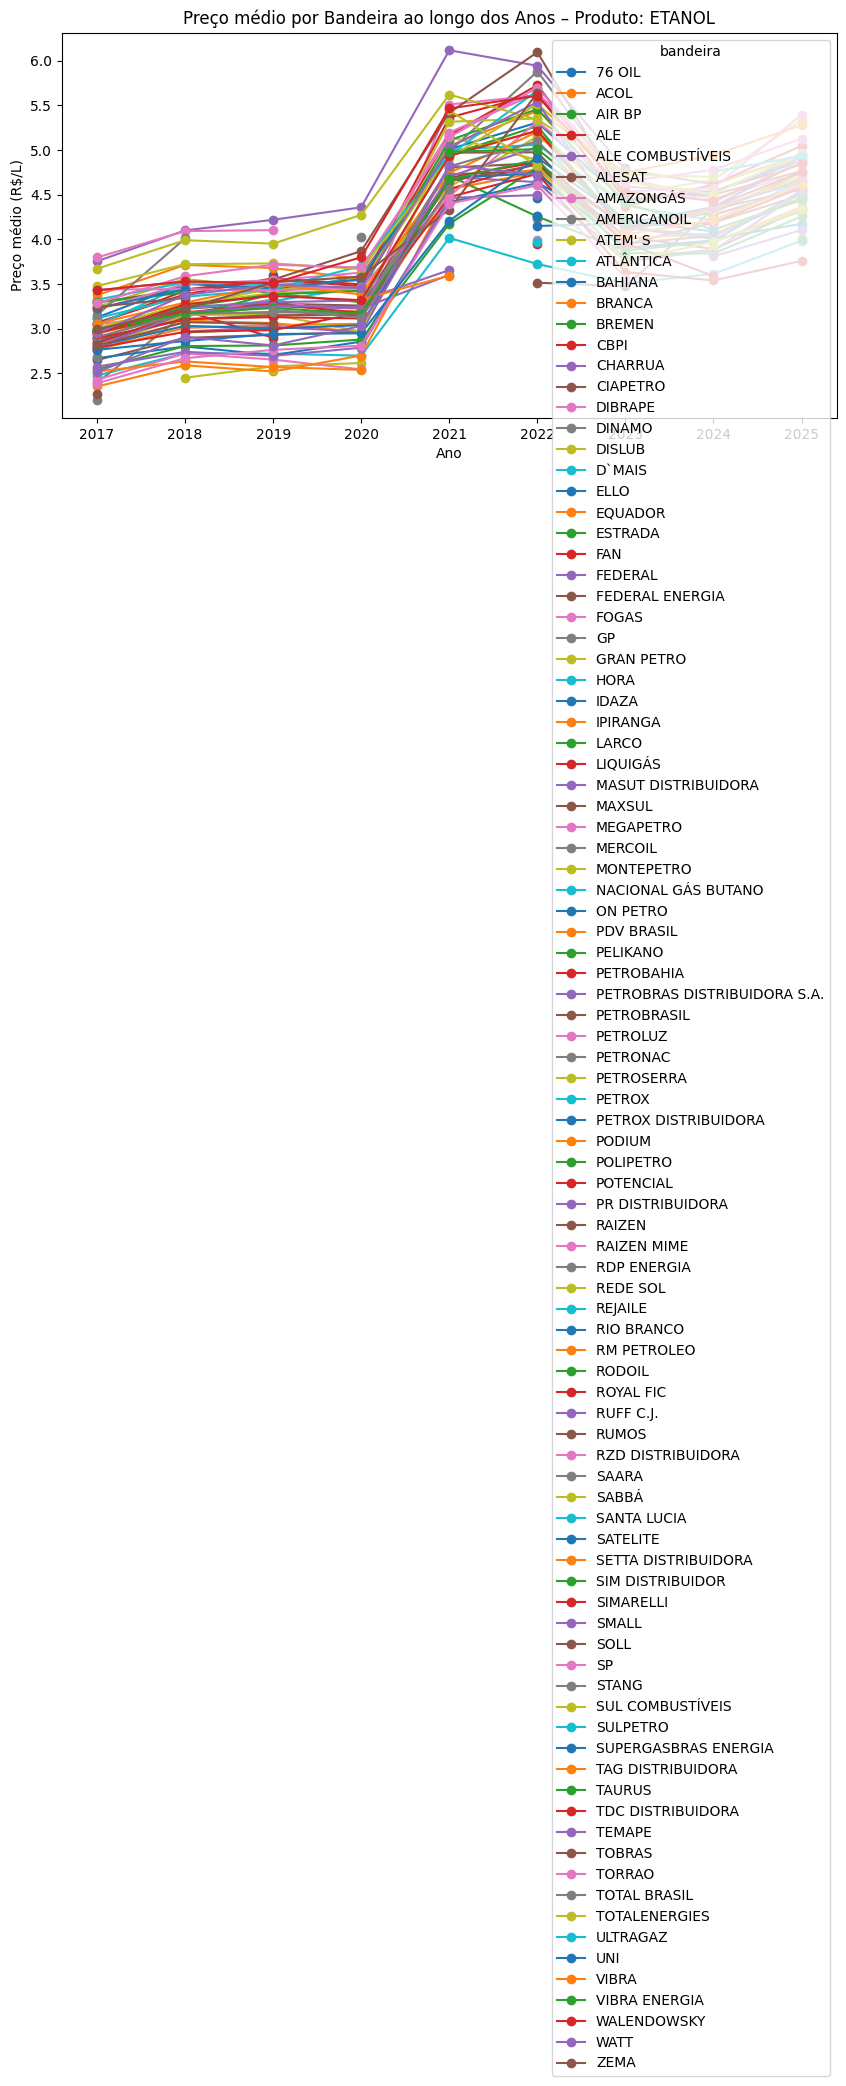

<Figure size 1000x500 with 0 Axes>

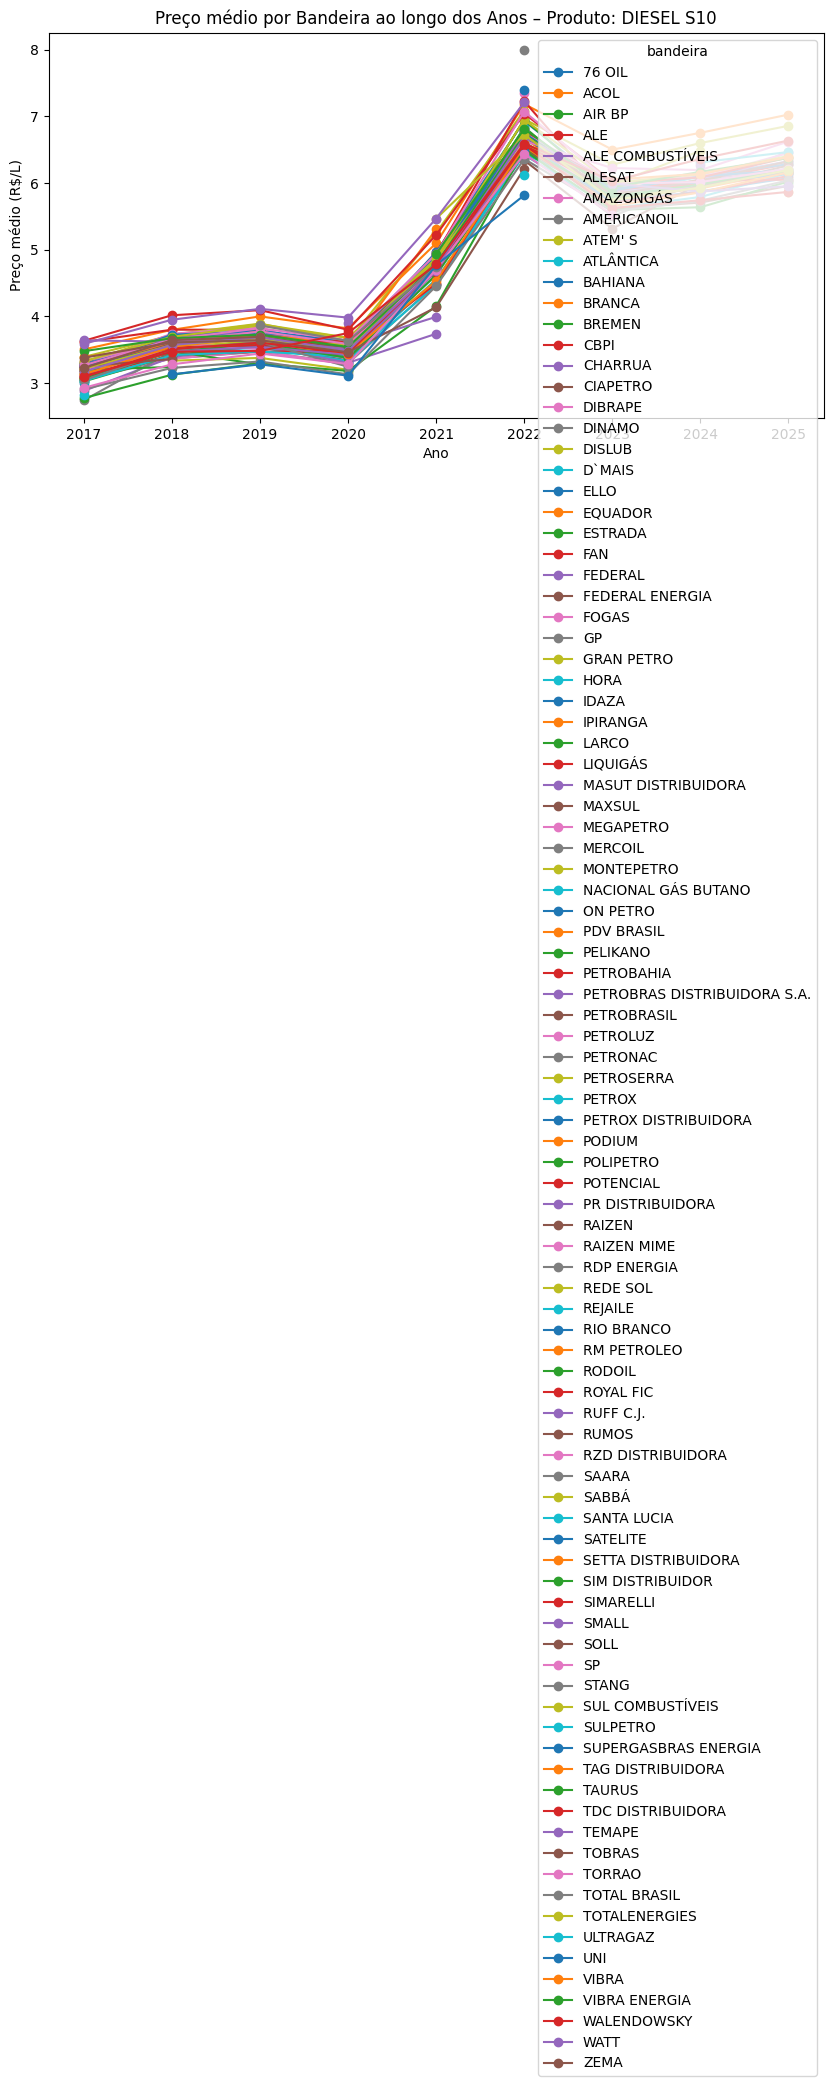

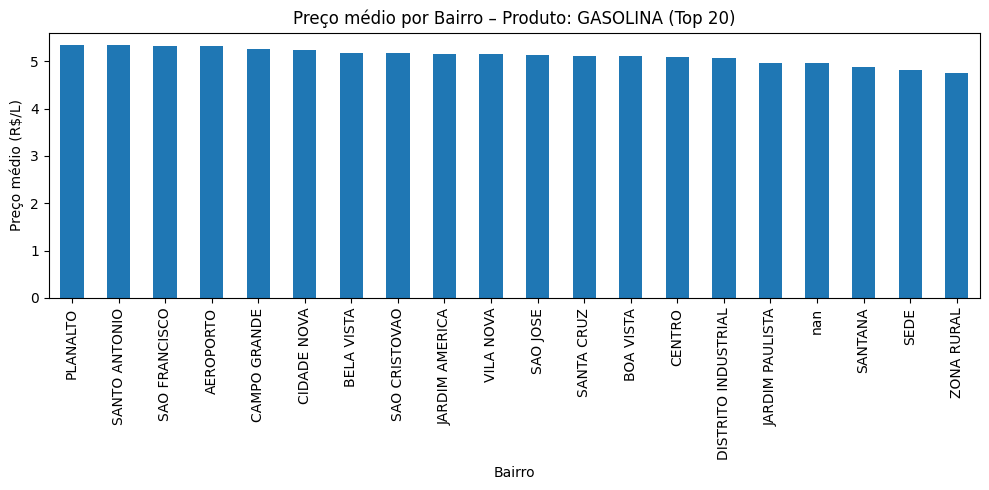

In [35]:
# ---------------------------------------------
# 7) Agrupamentos e Tabelas
# ---------------------------------------------
def safe_group_mean(df, by_cols, value_col="valor_venda"):
    g = df.groupby(by_cols, dropna=False)[value_col].agg(["count", "mean", "median", "std"])
    return g.sort_values("mean", ascending=False)

# 7.1 Preços de venda por REGIÃO
if "regiao_sigla" in df.columns:
    g_regiao = safe_group_mean(df, ["regiao_sigla"])
    print("\nPreço de venda por Região (count, mean, median, std):")
    display(g_regiao.head(20))
else:
    print("\n[AVISO] Coluna 'regiao_sigla' não encontrada. Pulando esse agrupamento.")
    g_regiao = None

# 7.2 Ano x Valor de Venda
if "ano" in df.columns:
    g_ano = safe_group_mean(df.dropna(subset=["ano"]), ["ano"])
    print("\nAno x Valor de Venda:")
    display(g_ano.head(50))
else:
    print("\n[AVISO] Coluna 'ano' não encontrada.")
    g_ano = None

# 7.3 Produto x Valor de Venda
if "produto" in df.columns:
    g_produto = safe_group_mean(df, ["produto"])
    print("\nProduto x Valor de Venda:")
    display(g_produto.head(50))
else:
    print("\n[AVISO] Coluna 'produto' não encontrada.")
    g_produto = None

# 7.4 Produto x Bandeira (tabela dinâmica)
if set(["produto", "bandeira"]).issubset(df.columns):
    pv_prod_band = pd.pivot_table(
        df, index="produto", columns="bandeira", values="valor_venda", aggfunc="mean"
    )
    print("\nPreço médio (R$) por Produto x Bandeira:")
    display(pv_prod_band.head(20))
else:
    print("\n[AVISO] Colunas para Produto x Bandeira não encontradas.")
    pv_prod_band = None

# 7.5 Bandeira x Ano x Produto (tabela dinâmica multiíndice)
if set(["bandeira", "ano", "produto"]).issubset(df.columns):
    pv_band_ano_prod = pd.pivot_table(
        df.dropna(subset=["ano"]),
        index=["ano", "produto"],
        columns="bandeira",
        values="valor_venda",
        aggfunc="mean",
    ).sort_index()
    print("\nPreço médio (R$) por Bandeira x Ano x Produto:")
    display(pv_band_ano_prod.head(40))
else:
    print("\n[AVISO] Colunas para Bandeira x Ano x Produto não encontradas.")
    pv_band_ano_prod = None

# 7.6 Produto x Bairro
if set(["produto", "bairro"]).issubset(df.columns):
    pv_prod_bairro = pd.pivot_table(
        df, index=["produto", "bairro"], values="valor_venda", aggfunc="mean"
    ).sort_values("valor_venda", ascending=False)
    print("\nPreço médio (R$) por Produto x Bairro:")
    display(pv_prod_bairro.head(40))
else:
    print("\n[AVISO] Colunas para Produto x Bairro não encontradas.")
    pv_prod_bairro = None

# ---------------------------------------------
# 8) Gráficos (matplotlib, 1 gráfico por figura, sem definir cores)
# ---------------------------------------------
plt.rcParams.update({"figure.figsize": (10, 5)})

# 8.1 Gráfico: preço médio por Região
if g_regiao is not None and not g_regiao.empty:
    plt.figure()
    g_regiao["mean"].sort_values(ascending=False).plot(kind="bar")
    plt.title("Preço médio de venda por Região (R$/L)")
    plt.xlabel("Região")
    plt.ylabel("Preço médio (R$/L)")
    plt.tight_layout()
    plt.show()

# 8.2 Gráfico: preço médio por Ano
if g_ano is not None and not g_ano.empty:
    plt.figure()
    # Ordena por ano ascendente (índice pode ser Int64)
    g_ano_sorted = g_ano.sort_index()
    g_ano_sorted["mean"].plot(kind="bar")
    plt.title("Preço médio de venda por Ano (R$/L)")
    plt.xlabel("Ano")
    plt.ylabel("Preço médio (R$/L)")
    plt.tight_layout()
    plt.show()

# 8.3 Gráfico: preço médio por Produto (top N para visibilidade)
TOP_N_PROD = 15
if g_produto is not None and not g_produto.empty:
    plt.figure()
    g_prod_top = g_produto.sort_values("mean", ascending=False).head(TOP_N_PROD)
    g_prod_top["mean"].plot(kind="bar")
    plt.title(f"Preço médio de venda por Produto (Top {TOP_N_PROD})")
    plt.xlabel("Produto")
    plt.ylabel("Preço médio (R$/L)")
    plt.tight_layout()
    plt.show()

# 8.4 Gráficos: Produto x Bandeira
#     - Gera um gráfico por produto (para os TOP M produtos por contagem)
TOP_M_PROD_BAND = 3
if set(["produto", "bandeira"]).issubset(df.columns):
    top_produtos = (
        df["produto"].value_counts().head(TOP_M_PROD_BAND).index.tolist()
    )
    for prod in top_produtos:
        sub = df[df["produto"] == prod]
        if sub.empty:
            continue
        g_band = sub.groupby("bandeira")["valor_venda"].mean().sort_values(ascending=False)
        plt.figure()
        g_band.plot(kind="bar")
        plt.title(f"Preço médio por Bandeira – Produto: {prod}")
        plt.xlabel("Bandeira")
        plt.ylabel("Preço médio (R$/L)")
        plt.tight_layout()
        plt.show()

# 8.5 Gráficos: Bandeira x Ano por Produto
#     - Para os TOP K produtos, linhas por bandeira ao longo dos anos
TOP_K_PROD_ANO_BAND = 3
if pv_band_ano_prod is not None:
    top_produtos_k = (
        df["produto"].value_counts().head(TOP_K_PROD_ANO_BAND).index.tolist()
    )
    for prod in top_produtos_k:
        if prod not in pv_band_ano_prod.index.get_level_values("produto"):
            continue
        wide = pv_band_ano_prod.xs(prod, level="produto")
        if wide.empty:
            continue
        plt.figure()
        wide.sort_index().plot(marker="o")
        plt.title(f"Preço médio por Bandeira ao longo dos Anos – Produto: {prod}")
        plt.xlabel("Ano")
        plt.ylabel("Preço médio (R$/L)")
        plt.tight_layout()
        plt.show()

# 8.6 Gráficos: Produto x Bairro
#     - Para um produto de foco (ou mais comuns), exibir Top N bairros por contagem
TOP_N_BAIRROS = 20
if set(["produto", "bairro"]).issubset(df.columns):
    # Seleciona produto com mais registros (ou defina manualmente em PRODUTO_FOCO)
    PRODUTO_FOCO = None
    if PRODUTO_FOCO is None:
        contagem_prod = df["produto"].value_counts()
        PRODUTO_FOCO = contagem_prod.index[0] if not contagem_prod.empty else None

    if PRODUTO_FOCO is not None:
        sub = df[df["produto"] == PRODUTO_FOCO]
        top_bairros = sub["bairro"].value_counts().head(TOP_N_BAIRROS).index
        g_bairro = (
            sub[sub["bairro"].isin(top_bairros)]
            .groupby("bairro")["valor_venda"]
            .mean()
            .sort_values(ascending=False)
        )
        plt.figure()
        g_bairro.plot(kind="bar")
        plt.title(f"Preço médio por Bairro – Produto: {PRODUTO_FOCO} (Top {TOP_N_BAIRROS})")
        plt.xlabel("Bairro")
        plt.ylabel("Preço médio (R$/L)")
        plt.tight_layout()
        plt.show()

# ---------------------------------------------
# 9) (Opcional) Exportar tabelas agregadas
# ---------------------------------------------
# g_regiao.to_csv("agg_preco_por_regiao.csv", encoding="utf-8")
# g_ano.to_csv("agg_preco_por_ano.csv", encoding="utf-8")
# g_produto.to_csv("agg_preco_por_produto.csv", encoding="utf-8")
# if pv_prod_band is not None: pv_prod_band.to_csv("pivot_produto_bandeira.csv", encoding="utf-8")
# if pv_band_ano_prod is not None: pv_band_ano_prod.to_csv("pivot_bandeira_ano_produto.csv", encoding="utf-8")
# if pv_prod_bairro is not None: pv_prod_bairro.to_csv("pivot_produto_bairro.csv", encoding="utf-8")



[1] Preço de venda por Região:


,count,mean,median,std
regiao_sigla,,,,
N,462922,5.131654,4.890,1.323826
NE,1465867,4.779390,4.590,1.276205
S,1243617,4.746758,4.589,1.292858
CO,643294,4.594737,4.300,1.304823
SE,3597221,4.541628,4.299,1.314172


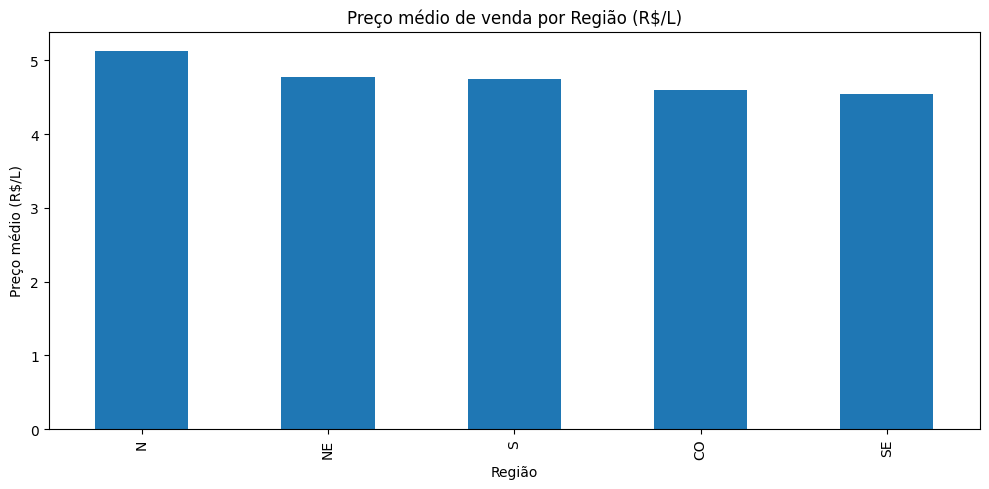


[2] Ano x Valor de Venda:


,count,mean,median,std
ano,,,,
2022,907502,6.117853,6.290,1.136970
2025,420409,5.890884,6.170,0.893260
2024,898536,5.558804,5.860,0.918802
2023,904000,5.302210,5.490,0.877348
2021,807537,5.237572,5.199,0.926472
2019,1004029,3.748456,3.699,0.597086
2018,963002,3.702545,3.599,0.628194
2020,719300,3.654332,3.609,0.624924
2017,788606,3.263891,3.210,0.479330


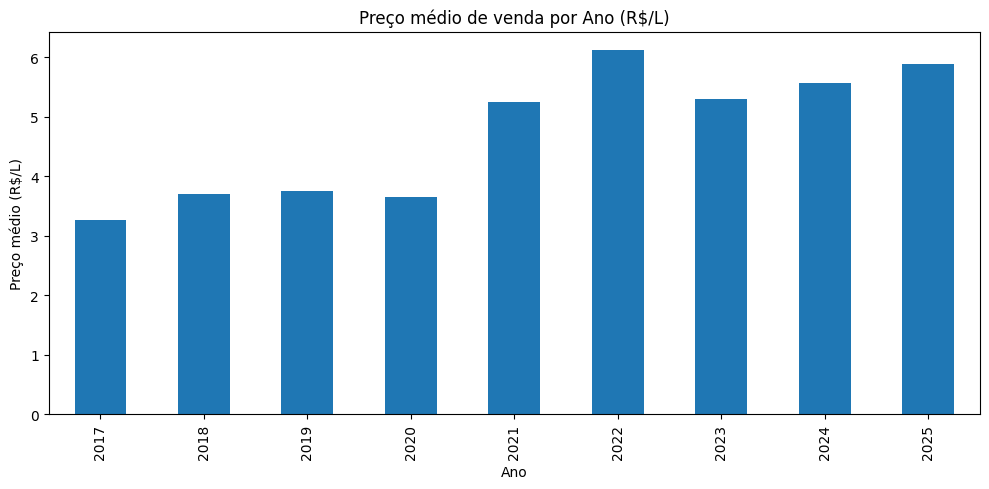


[3] Produto x Valor de Venda:


,count,mean,median,std
produto,,,,
GASOLINA ADITIVADA,787465,6.096450,6.050,0.732445
GASOLINA,2061993,5.086179,4.890,1.032892
DIESEL S10,1599614,4.658235,3.990,1.361528
DIESEL,1021697,4.473640,3.790,1.355359
GNV,135450,3.915256,3.999,1.047754
ETANOL,1806702,3.728812,3.599,0.905648


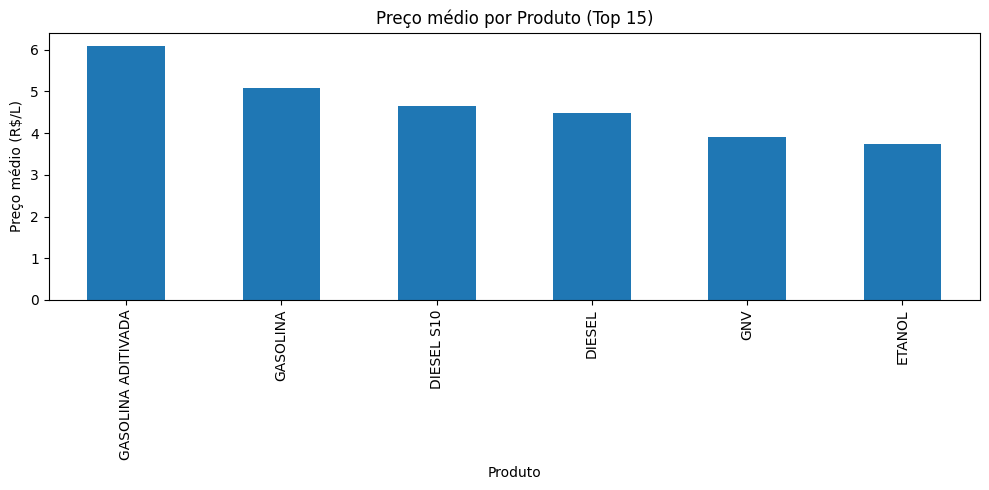


[4] Produto x Bandeira – preço médio (R$):


bandeira,76 OIL,ACOL,AIR BP,ALE,ALE COMBUSTÍVEIS,ALESAT,AMAZONGÁS,AMERICANOIL,ATEM' S,ATLÂNTICA,BAHIANA,BRANCA,BREMEN,CBPI,CHARRUA,CIAPETRO,DIBRAPE,DINAMO,DISLUB,D`MAIS,ELLO,EQUADOR,ESTRADA,FAN,FEDERAL,FEDERAL ENERGIA,FOGAS,GP,GRAN PETRO,HORA,IDAZA,IPIRANGA,LARCO,LIQUIGÁS,MASUT DISTRIBUIDORA,MAXSUL,MEGAPETRO,MERCOIL,MONTEPETRO,NACIONAL GÁS BUTANO,ON PETRO,PDV BRASIL,PELIKANO,PETROBAHIA,PETROBRAS DISTRIBUIDORA S.A.,PETROBRASIL,PETROLUZ,PETRONAC,PETROSERRA,PETROX,PETROX DISTRIBUIDORA,PODIUM,POLIPETRO,POTENCIAL,PR DISTRIBUIDORA,RAIZEN,RAIZEN MIME,RDP ENERGIA,REDE SOL,REJAILE,RIO BRANCO,RM PETROLEO,RODOIL,ROYAL FIC,RUFF C.J.,RUMOS,RZD DISTRIBUIDORA,SAARA,SABBÁ,SANTA LUCIA,SATELITE,SETTA DISTRIBUIDORA,SIM DISTRIBUIDOR,SIMARELLI,SMALL,SOLL,SP,STANG,SUL COMBUSTÍVEIS,SULPETRO,SUPERGASBRAS ENERGIA,TAG DISTRIBUIDORA,TAURUS,TDC DISTRIBUIDORA,TEMAPE,TOBRAS,TORRAO,TOTAL BRASIL,TOTALENERGIES,ULTRAGAZ,UNI,VIBRA,VIBRA ENERGIA,WALENDOWSKY,WATT,ZEMA
produto,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
DIESEL,3.599,3.420426,5.658421,6.028492,3.206190,4.440033,7.390000,4.655147,4.750720,4.136086,NaN,4.444078,NaN,3.079477,4.774377,4.206589,4.566923,NaN,4.690691,4.066976,NaN,4.906490,5.070212,4.358044,3.450792,5.783511,6.776000,3.250743,3.251889,3.449989,4.696864,4.628434,5.359020,6.380000,4.820294,5.006648,3.296653,NaN,4.385525,NaN,5.815000,NaN,4.237842,4.288534,3.476230,5.966000,3.567124,2.966778,3.783164,3.159857,4.597998,3.601108,3.599000,4.791659,NaN,4.439405,4.227257,NaN,NaN,3.472775,4.286885,3.071442,4.852042,5.376744,3.350853,NaN,4.522091,2.997868,4.817881,6.267874,3.189147,4.515669,5.94125,4.319911,4.312526,3.152500,4.193319,4.408468,4.987717,2.710174,6.570000,3.995000,4.843061,3.568463,5.011162,3.432384,3.577886,3.929646,6.087505,6.626667,2.932424,6.109793,5.869876,5.467192,4.538806,3.413466
DIESEL S10,NaN,3.524203,5.667500,6.138259,3.314648,4.695210,7.356667,4.263501,5.054909,4.689375,7.390,4.712116,3.399,3.183049,4.889528,4.418013,4.522902,NaN,4.589166,4.312337,2.999,5.119812,5.137452,4.639414,3.201585,5.692636,6.792222,3.308114,3.307333,3.244000,4.564119,4.728710,5.422079,5.668880,5.007478,5.110479,3.476651,NaN,4.470079,6.783333,5.878152,3.138545,4.293183,4.716418,3.585634,5.588636,3.632141,3.168370,3.874315,3.268837,4.645522,3.820156,3.232765,4.975365,3.899,4.563861,4.321810,NaN,3.282333,3.615496,4.590770,3.111012,5.071962,4.370034,3.838007,NaN,4.792378,3.163083,4.693351,6.374151,3.336845,4.320398,6.00375,4.659090,4.210742,3.299167,4.533138,4.519146,5.116988,2.821609,6.490000,3.695000,4.843813,4.032809,5.168190,3.705460,3.865736,4.181770,6.077030,6.112000,3.925227,6.175423,5.952127,5.383521,4.442604,3.507163
ETANOL,3.599,2.924324,4.712500,4.392821,2.997718,3.730887,4.223333,3.983160,4.117108,4.084178,4.465,3.651581,2.599,2.963882,4.502036,3.400803,3.928432,NaN,4.125238,2.988555,2.969,4.325715,3.741079,4.017907,3.073566,4.621139,3.990000,2.995771,2.567750,3.319032,3.353311,3.743836,4.226752,3.698129,3.587281,4.358298,3.967679,2.199,3.565269,4.260000,4.357520,3.305250,3.471907,4.030153,3.217506,3.591304,2.611880,2.748370,3.595809,3.273108,4.138602,2.687883,3.386444,3.836943,3.189,3.702643,4.237320,NaN,2.540667,3.469919,3.539413,2.552843,4.149568,3.480066,2.922950,2.269,4.473651,3.449973,4.338111,4.844797,3.287324,3.873563,4.00375,3.528533,3.760231,3.292800,4.108820,3.850350,4.249087,NaN,4.267000,3.415000,3.759136,3.726336,4.383459,3.434125,3.083734,3.772896,4.238240,3.965714,3.564056,4.274266,4.827862,4.657407,3.287432,2.969650
GASOLINA,4.699,4.335192,5.854500,6.142229,3.938582,5.015351,5.280000,4.749420,5.295862,4.990202,4.665,5.052997,3.999,3.757149,5.271694,4.894424,5.008207,NaN,5.173787,4.434912,3.620,5.435072,5.436337,5.096675,3.945286,6.011849,5.207778,4.310143,4.084625,4.402305,4.844075,5.116085,5.582822,4.632947,5.251806,5.384574,4.455310,3.279,5.149379,4.724000,6.174560,3.635957,4.772177,5.199300,4.323797,4.980204,4.212406,3.644457,4.636364,3.946884,5.215785,4.317772,4.107579,5

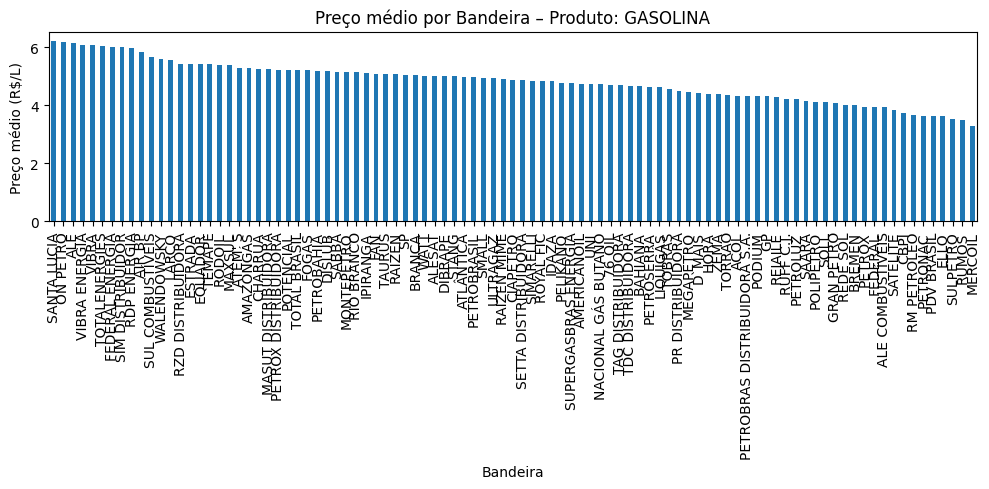

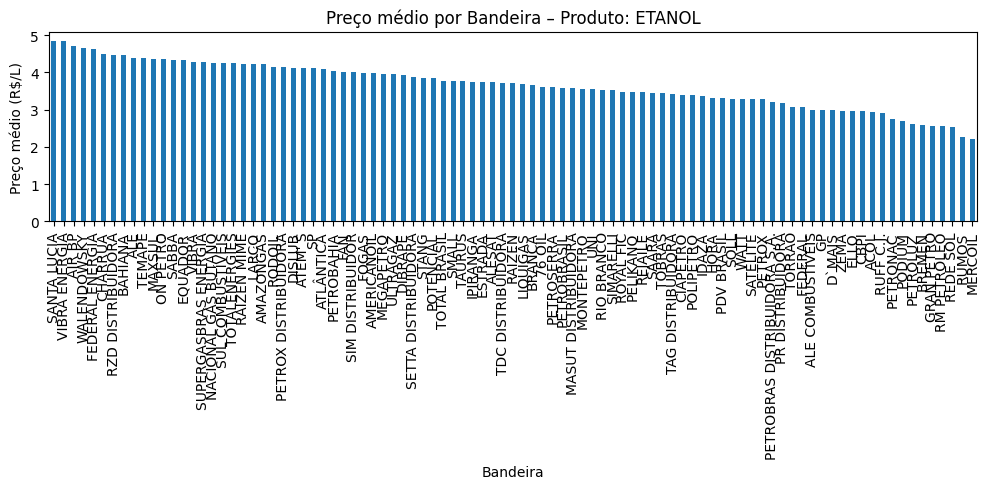

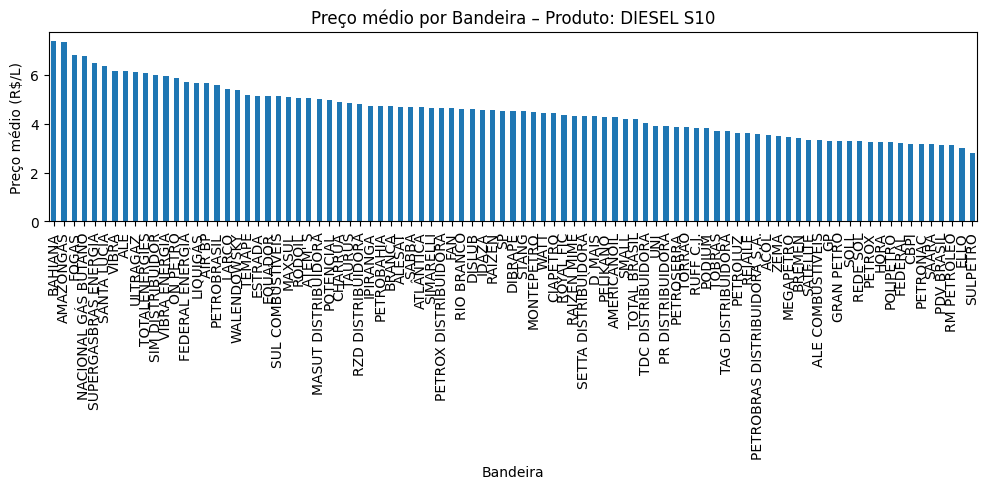


[5] Bandeira x Ano x Produto – estatísticas:


,,,count,mean,median,std
bandeira,ano,produto,,,,
PETRONAC,2022,DIESEL S10,1,7.990000,7.9900,NaN
WATT,2022,GASOLINA ADITIVADA,18,7.446111,7.7300,0.564740
BAHIANA,2022,DIESEL S10,1,7.390000,7.3900,NaN
AMAZONGÁS,2022,DIESEL,1,7.390000,7.3900,NaN
TOBRAS,2022,GASOLINA ADITIVADA,4,7.365000,7.3400,0.457347
AMAZONGÁS,2022,DIESEL S10,3,7.356667,7.3900,0.104083
TOBRAS,2022,GASOLINA,4,7.315000,7.2400,0.394757
PODIUM,2021,GASOLINA ADITIVADA,17,7.299000,6.9990,0.520817
PETROBAHIA,2022,DIESEL S10,132,7.226667,7.3000,0.737579



[5] (Pivot) Preço médio – Bandeira x Ano x Produto:


bandeira                 76 OIL      ACOL    AIR BP      ALE  ALE COMBUSTÍVEIS    ALESAT  AMAZONGÁS  AMERICANOIL  \
ano  produto                                                                                                       
2017 DIESEL                 NaN  3.140308       NaN      NaN          3.096919  3.112576        NaN          NaN   
     DIESEL S10             NaN  3.285440       NaN      NaN          3.201598  3.224092        NaN     3.052809   
     ETANOL                 NaN  2.757008       NaN      NaN          2.893365  2.960265        NaN     3.427794   
     GASOLINA               NaN  3.885087       NaN      NaN          3.725705  3.805085        NaN     3.597162   
     GNV                    NaN       NaN       NaN      NaN          2.154743  2.326665        NaN     2.938261   
2018 DIESEL                 NaN  3.582418       NaN      NaN          3.444904  3.536070        NaN     3.276750   
     DIESEL S10             NaN  3.702891       NaN      NaN          3.523927  3.608628        NaN     3.368122   
     ETANOL                 NaN  3.089700       NaN      NaN          3.211765  3.224303        NaN     3.531557   
     GASOLINA               NaN  4.762967       NaN      NaN          4.321838  4.490534        NaN     4.149240   
     GNV                    NaN       NaN       NaN      NaN          2.471688  2.785532        NaN     3.015731   
2019 DIESEL               3.599  3.604824       NaN      NaN               NaN  3.624106        NaN     3.381153   
     DIESEL S10             NaN  3.672417  3.550000      NaN               NaN  3.704064        NaN     3.470211   
     ETANOL               3.599  3.063000  3.150000      NaN               NaN  3.280275        NaN     3.394603   
     GASOLINA             4.699  4.758368  4.450000      NaN               NaN  4.503567        NaN     4.121585   
     GNV                    NaN       NaN       NaN      NaN               NaN  3.302833        NaN     3.171000   
2020 DIESEL                 NaN  3.451481       NaN      NaN               NaN  3.440985        NaN     3.228413   
     DIESEL S10             NaN  3.578000       NaN      NaN               NaN  3.522991        NaN     3.294696   
     ETANOL                 NaN  2.958704       NaN      NaN               NaN  3.258726        NaN     3.593891   
     GASOLINA               NaN  4.414185       NaN      NaN               NaN  4.350062        NaN     4.193368   
     GASOLINA ADITIVADA     NaN       NaN       NaN      NaN               NaN  4.627581        NaN     4.451000   
     GNV                    NaN       NaN       NaN      NaN               NaN  3.203645        NaN     2.949000   
2021 DIESEL                 NaN       NaN       NaN      NaN               NaN  4.728078        NaN     4.502269   
     DIESEL S10             NaN       NaN       NaN      NaN               NaN  4.777120        NaN     4.486397   
     ETANOL                 NaN       NaN       NaN      NaN               NaN  4.803120        NaN     4.985292   
     GASOLINA               NaN       NaN       NaN      NaN               NaN  6.004958        NaN     5.708627   
     GASOLINA ADITIVADA     NaN       NaN       NaN      NaN               NaN  6.074850        NaN     5.796780   
     GNV                    NaN       NaN       NaN      NaN               NaN  3.946558        NaN     3.754952   
2022 DIESEL                 NaN       NaN       NaN      NaN               NaN  6.644896   7.390000     6.394957   
     DIESEL S10             NaN       NaN       NaN      NaN               NaN  6.775541   7.356667     6.506583   
     ETANOL                 NaN       NaN       NaN      NaN               NaN  4.852495   4.223333     5.878571   
     GASOLINA               NaN       NaN       NaN      NaN               NaN  6.293082   5.280000     6.491321   
     GASOLINA ADITIVADA     NaN       NaN       NaN      NaN               NaN  6.425745   5.320000     6.689612   
     GNV                    NaN       NaN       NaN     

<Figure size 1000x500 with 0 Axes>

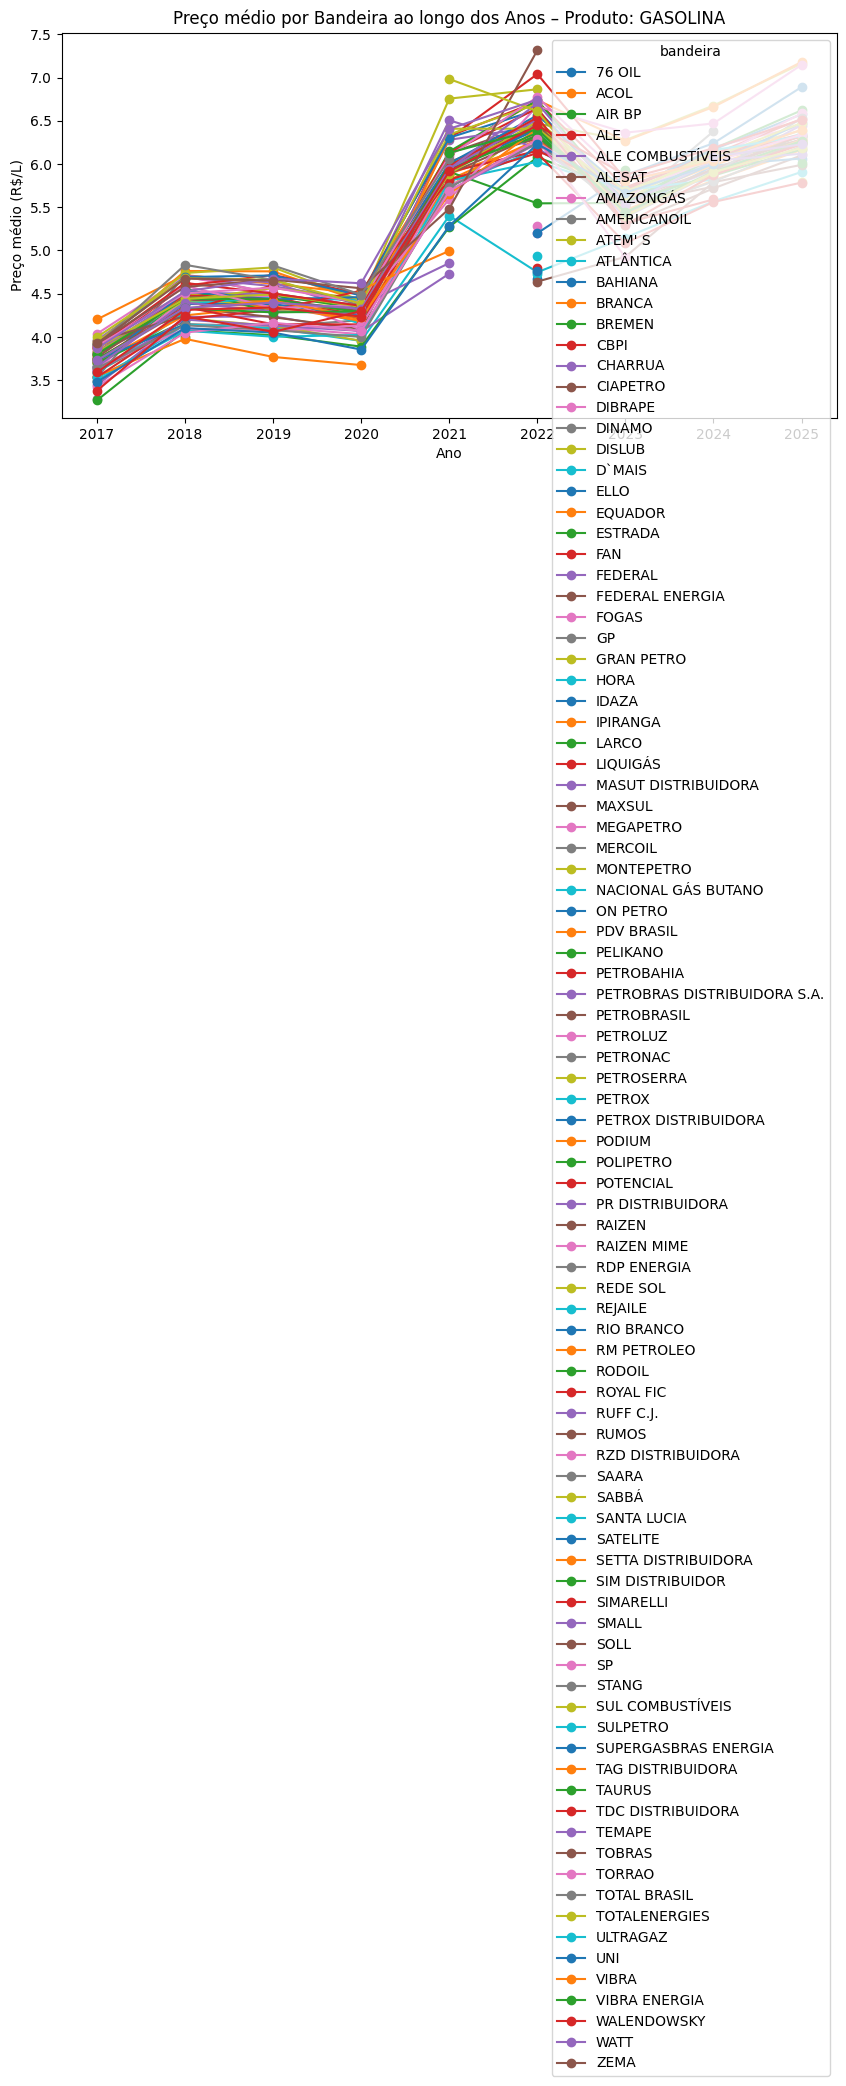

<Figure size 1000x500 with 0 Axes>

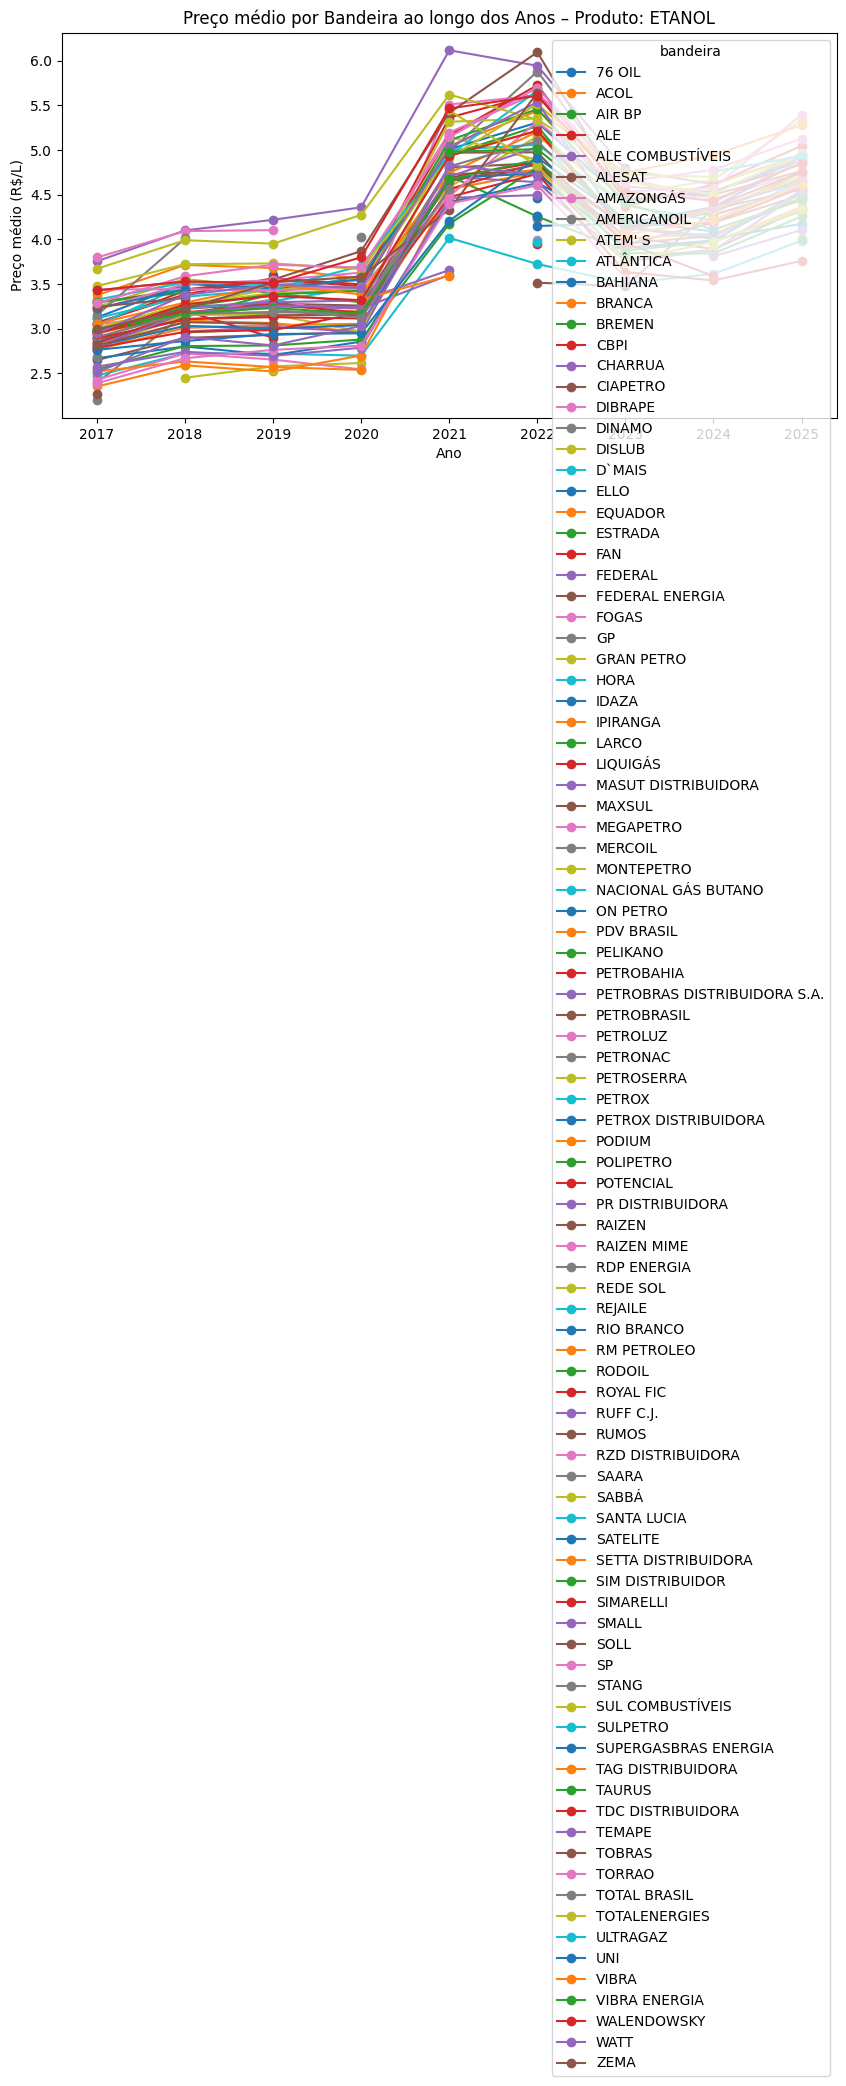

<Figure size 1000x500 with 0 Axes>

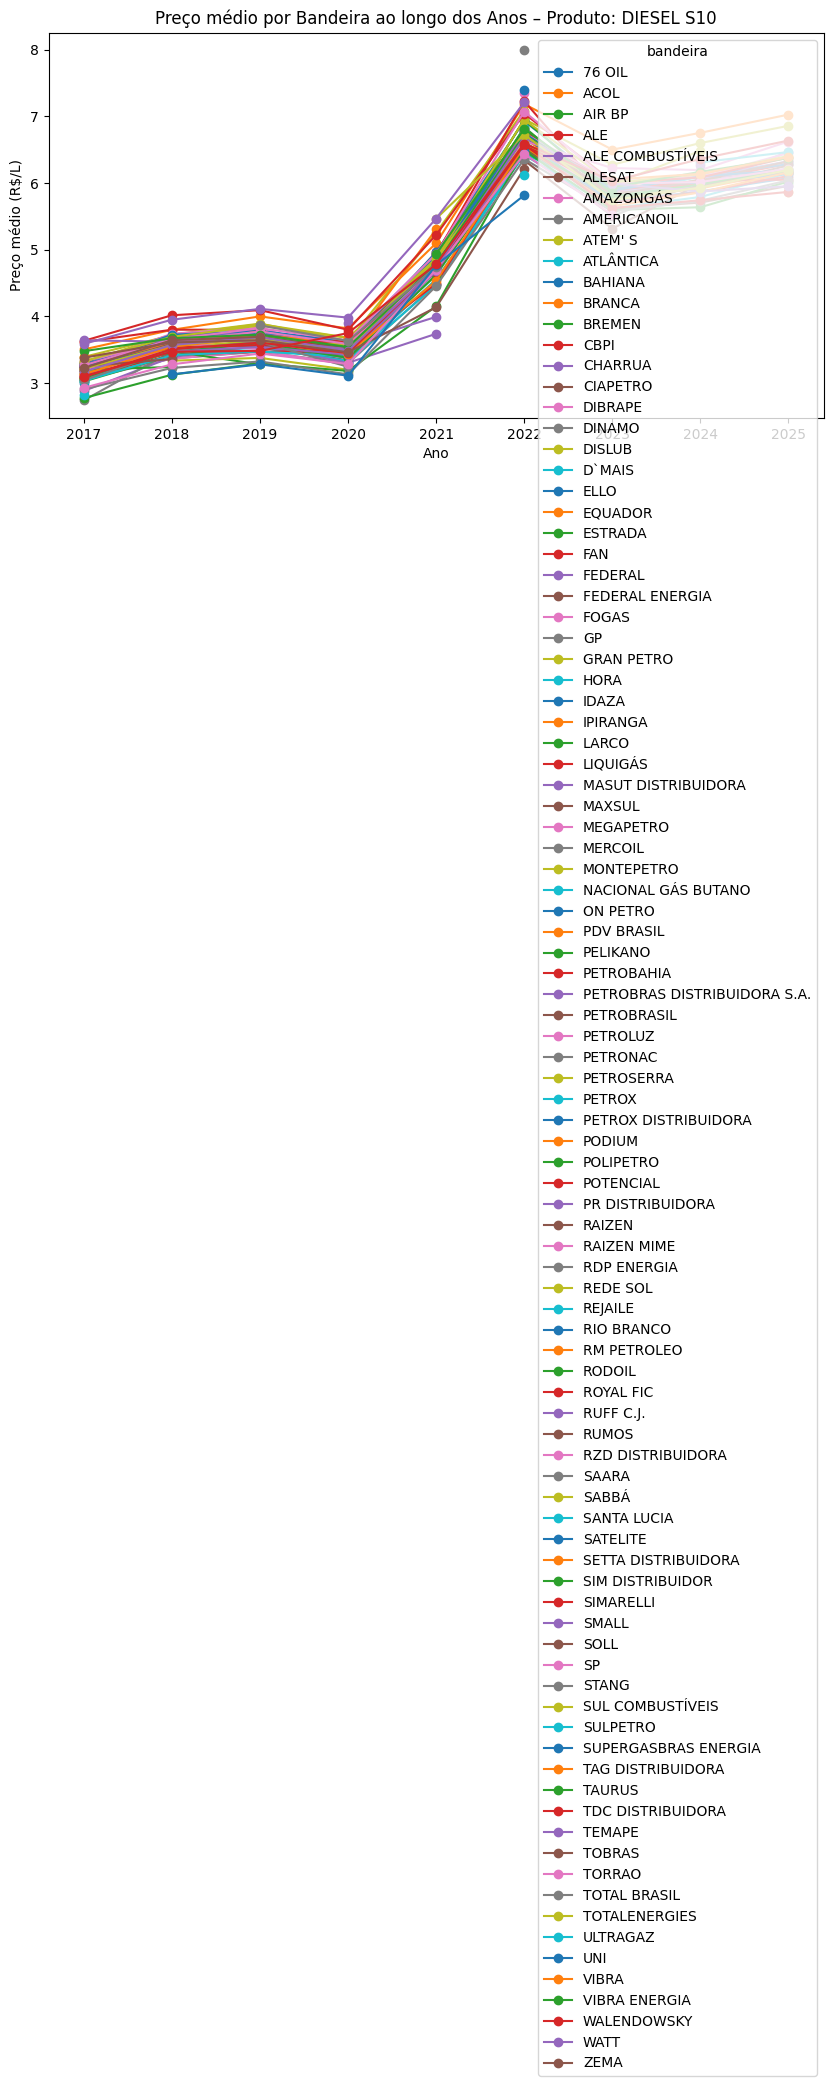


[6] Produto x Município – preço médio (R$):


municipio,ABAETETUBA,ABREU E LIMA,ACAILANDIA,ADAMANTINA,AGUAS LINDAS DE GOIAS,ALAGOINHAS,ALEGRETE,ALENQUER,ALFENAS,ALTA FLORESTA,ALTAMIRA,ALVORADA,AMARANTE DO MARANHAO,AMELIA RODRIGUES,AMERICANA,AMPARO,ANAMA,ANANINDEUA,ANAPOLIS,ANGRA DOS REIS
produto,,,,,,,,,,,,,,,,,,,,
DIESEL,4.469818,NaN,4.523385,4.178656,5.105300,4.444973,4.688228,5.646400,4.745372,4.748696,5.547240,4.854001,NaN,2.750767,4.579923,4.214583,3.100000,5.561179,4.487789,5.456293
DIESEL S10,5.122537,2.886962,4.723326,4.493980,5.186719,4.552628,4.726526,6.029881,4.960140,4.907099,5.581391,4.789244,NaN,2.825533,4.590216,4.276891,NaN,4.880438,4.984749,5.276300
ETANOL,4.664451,2.840324,4.161058,3.080009,3.692803,3.802746,4.612220,6.231303,3.606821,3.425467,4.981277,4.575855,4.375714,2.785133,3.278219,3.325260,NaN,4.085514,3.398950,4.760658
GASOLINA,5.617314,3.404943,5.033496,4.848479,5.353786,4.986835,5.389835,5.866112,5.335011,5.290348,5.960755,5.224599,5.101429,3.445267,4.827510,4.741926,4.268923,4.965912,5.078891,5.831788
GASOLINA ADITIVADA,6.387369,NaN,6.144878,5.910887,6.105629,6.105424,6.409532,6.793021,6.109078,6.775266,6.781903,5.921504,NaN,NaN,5.868865,5.953813,NaN,5.900873,5.938288,6.698127
GNV,NaN,2.212909,NaN,NaN,3.890000,4.173213,NaN,NaN,NaN,NaN,5.500000,4.479582,NaN,1.999000,3.071000,5.540000,NaN,NaN,NaN,6.288319


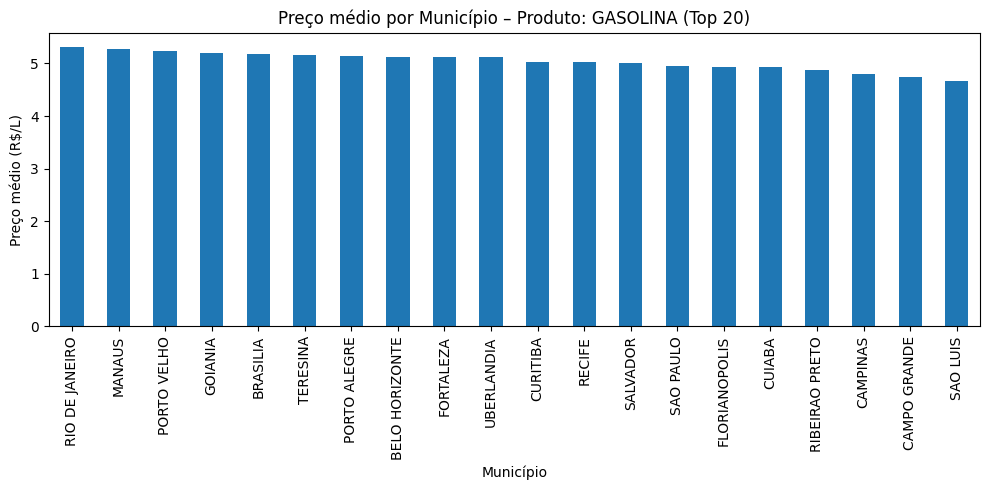

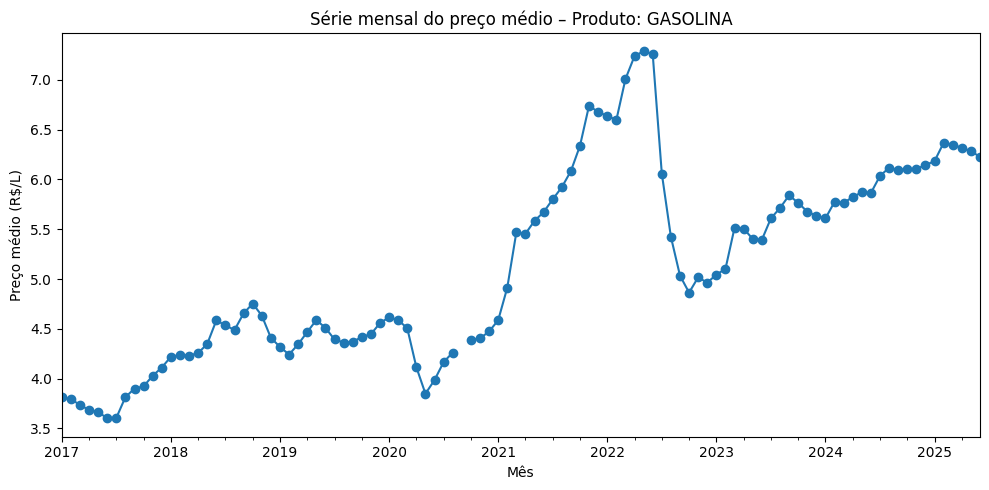

<Figure size 1000x500 with 0 Axes>

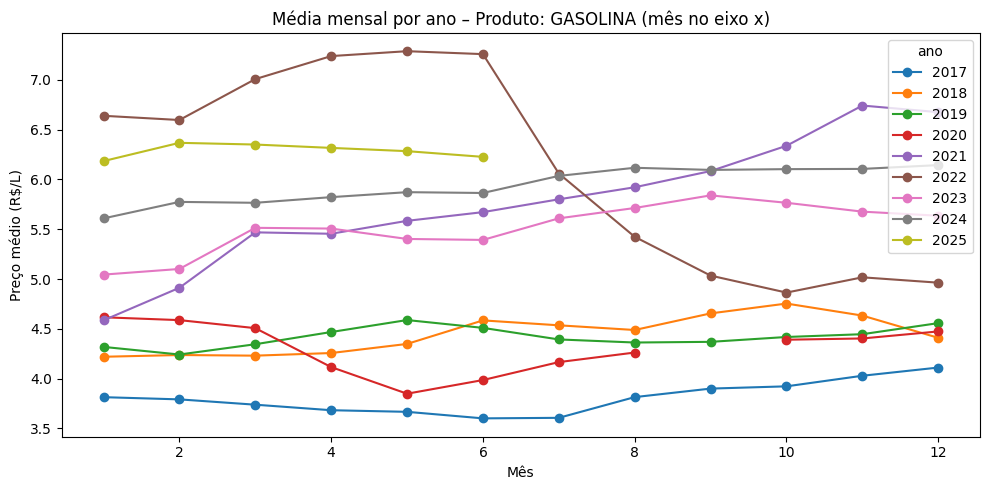

In [39]:
TOP_N_PROD = 15
TOP_M_PROD_BAND = 3
TOP_K_PROD_ANO_BAND = 3
TOP_N_MUNICIPIOS = 20


# 6.1 Preços de venda por REGIÃO
if "regiao_sigla" in df.columns:
    g_regiao = safe_group_mean(df, ["regiao_sigla"])
    print("\n[1] Preço de venda por Região:")
    display(g_regiao)
    # Gráfico
    plt.figure()
    g_regiao["mean"].sort_values(ascending=False).plot(kind="bar")
    plt.title("Preço médio de venda por Região (R$/L)")
    plt.xlabel("Região")
    plt.ylabel("Preço médio (R$/L)")
    plt.tight_layout()
    plt.show()
else:
    print("\n[1] 'regiao_sigla' não encontrada.")
    g_regiao = None

# 6.2 Ano - Valor de Venda
if "ano" in df.columns:
    g_ano = safe_group_mean(df.dropna(subset=["ano"]), ["ano"])
    print("\n[2] Ano x Valor de Venda:")
    display(g_ano)
    # Gráfico
    plt.figure()
    g_ano.sort_index()["mean"].plot(kind="bar")
    plt.title("Preço médio de venda por Ano (R$/L)")
    plt.xlabel("Ano")
    plt.ylabel("Preço médio (R$/L)")
    plt.tight_layout()
    plt.show()
else:
    print("\n[2] 'ano' não encontrada.")
    g_ano = None

# 6.3 Produto - Valor de Venda
if "produto" in df.columns:
    g_produto = safe_group_mean(df, ["produto"])
    print("\n[3] Produto x Valor de Venda:")
    display(g_produto)
    # Gráfico (Top N)
    plt.figure()
    g_prod_top = g_produto.head(TOP_N_PROD)
    g_prod_top["mean"].plot(kind="bar")
    plt.title(f"Preço médio por Produto (Top {TOP_N_PROD})")
    plt.xlabel("Produto")
    plt.ylabel("Preço médio (R$/L)")
    plt.tight_layout()
    plt.show()
else:
    print("\n[3] 'produto' não encontrada.")
    g_produto = None

# 6.4 Produto por Bandeira (pivot de médias)
if set(["produto", "bandeira"]).issubset(df.columns):
    pv_prod_band = pd.pivot_table(df, index="produto", columns="bandeira",
                                  values="valor_venda", aggfunc="mean")
    print("\n[4] Produto x Bandeira – preço médio (R$):")
    display(pv_prod_band)
    # Gráfico por produto (Top M por contagem)
    top_produtos = df["produto"].value_counts().head(TOP_M_PROD_BAND).index.tolist()
    for prod in top_produtos:
        sub = df[df["produto"] == prod]
        g_band = sub.groupby("bandeira")["valor_venda"].mean().sort_values(ascending=False)
        plt.figure()
        g_band.plot(kind="bar")
        plt.title(f"Preço médio por Bandeira – Produto: {prod}")
        plt.xlabel("Bandeira")
        plt.ylabel("Preço médio (R$/L)")
        plt.tight_layout()
        plt.show()
else:
    print("\n[4] Faltam colunas 'produto' e/ou 'bandeira'.")
    pv_prod_band = None

# 6.5 Bandeira por Ano por Produto
if set(["bandeira", "ano", "produto"]).issubset(df.columns):
    grp_band_ano_prod = df.dropna(subset=["ano"]).groupby(
        ["bandeira", "ano", "produto"]
    )["valor_venda"].agg(["count", "mean", "median", "std"]).sort_values("mean", ascending=False)
    print("\n[5] Bandeira x Ano x Produto – estatísticas:")
    display(grp_band_ano_prod)

    pv_band_ano_prod = pd.pivot_table(
        df.dropna(subset=["ano"]),
        index=["ano", "produto"],
        columns="bandeira",
        values="valor_venda",
        aggfunc="mean"
    ).sort_index()
    print("\n[5] (Pivot) Preço médio – Bandeira x Ano x Produto:")
    display(pv_band_ano_prod.head(40))

    # Gráficos ao longo dos anos para TOP K produtos
    top_k = df["produto"].value_counts().head(TOP_K_PROD_ANO_BAND).index.tolist()
    for prod in top_k:
        if prod in pv_band_ano_prod.index.get_level_values("produto"):
            wide = pv_band_ano_prod.xs(prod, level="produto")
            if not wide.empty:
                plt.figure()
                wide.sort_index().plot(marker="o")  # uma figura por gráfico
                plt.title(f"Preço médio por Bandeira ao longo dos Anos – Produto: {prod}")
                plt.xlabel("Ano")
                plt.ylabel("Preço médio (R$/L)")
                plt.tight_layout()
                plt.show()
else:
    print("\n[5] Faltam 'bandeira', 'ano' e/ou 'produto'.")
    pv_band_ano_prod = None

PRODS_FOCO = []

# 6.6 Produto por MUNICÍPIO
if set(["produto", "municipio"]).issubset(df.columns):
    pv_prod_mun = pd.pivot_table(
        df, index="produto", columns="municipio", values="valor_venda", aggfunc="mean"
    )
    print("\n[6] Produto x Município – preço médio (R$):")
    display(pv_prod_mun.iloc[:20, :20])  # vista parcial
    # Gráfico: para produto foco, Top N municípios por contagem
    if not PRODS_FOCO:
        PRODS_FOCO = [df["produto"].value_counts().index[0]]
    for prod in PRODS_FOCO:
        sub = df[df["produto"] == prod]
        top_muns = sub["municipio"].value_counts().head(TOP_N_MUNICIPIOS).index
        g_mun = (sub[sub["municipio"].isin(top_muns)]
                 .groupby("municipio")["valor_venda"].mean()
                 .sort_values(ascending=False))
        plt.figure()
        g_mun.plot(kind="bar")
        plt.title(f"Preço médio por Município – Produto: {prod} (Top {TOP_N_MUNICIPIOS})")
        plt.xlabel("Município")
        plt.ylabel("Preço médio (R$/L)")
        plt.tight_layout()
        plt.show()
else:
    print("\n[6] Faltam colunas 'produto' e/ou 'municipio'.")
    pv_prod_mun = None

# ---------------------------
# 7) SÉRIE TEMPORAL MENSAL por PRODUTO
#    (ex.: Gasolina mensal em 2017, 2018, ...)
# ---------------------------
if "data_coleta" in df.columns and "produto" in df.columns:
    # Média mensal por produto
    monthly = (df.set_index("data_coleta")
                 .groupby("produto")["valor_venda"]
                 .resample("M").mean()
                 .rename("valor_venda")
                 .reset_index())

    # Gráfico 7.1: série mensal completa por produto (um gráfico por produto foco)
    if not PRODS_FOCO:
        PRODS_FOCO = [df["produto"].value_counts().index[0]]

    for prod in PRODS_FOCO:
        mprod = monthly[monthly["produto"] == prod].sort_values("data_coleta")
        if mprod.empty:
            continue
        plt.figure()
        mprod.set_index("data_coleta")["valor_venda"].plot(marker="o")
        plt.title(f"Série mensal do preço médio – Produto: {prod}")
        plt.xlabel("Mês")
        plt.ylabel("Preço médio (R$/L)")
        plt.tight_layout()
        plt.show()

        # Gráfico 7.2: "mensal em 2017, 2018, ..." – linhas por ano com eixo x = mês (1..12)
        mprod["ano"] = mprod["data_coleta"].dt.year
        mprod["mes"] = mprod["data_coleta"].dt.month
        pivot_mes_ano = mprod.pivot_table(index="mes", columns="ano", values="valor_venda", aggfunc="mean")
        pivot_mes_ano = pivot_mes_ano.sort_index()  # meses 1..12
        plt.figure()
        pivot_mes_ano.plot(marker="o")
        plt.title(f"Média mensal por ano – Produto: {prod} (mês no eixo x)")
        plt.xlabel("Mês")
        plt.ylabel("Preço médio (R$/L)")
        plt.tight_layout()
        plt.show()
else:
    print("\n[7] Série temporal mensal indisponível: verifique 'data_coleta' e 'produto'.")

# ---------------------------
# 8) (Opcional) Exportar agregações
# ---------------------------
# if 'g_regiao' in locals() and g_regiao is not None: g_regiao.to_csv("agg_preco_por_regiao.csv", encoding="utf-8")
# if 'g_ano' in locals() and g_ano is not None: g_ano.to_csv("agg_preco_por_ano.csv", encoding="utf-8")
# if 'g_produto' in locals() and g_produto is not None: g_produto.to_csv("agg_preco_por_produto.csv", encoding="utf-8")
# if 'pv_prod_band' in locals() and pv_prod_band is not None: pv_prod_band.to_csv("pivot_produto_bandeira.csv", encoding="utf-8")
# if 'pv_band_ano_prod' in locals() and pv_band_ano_prod is not None: pv_band_ano_prod.to_csv("pivot_bandeira_ano_produto.csv", encoding="utf-8")
# if 'pv_prod_mun' in locals() and pv_prod_mun is not None: pv_prod_mun.to_csv("pivot_produto_municipio.csv", encoding="utf-8")


In [14]:
rio = folium.Map(location=[-22.9035, -43.2096])

In [15]:
rio

In [26]:
folium.Marker(
    [-22.9035, -43.2096],
    popup='<i>Rio de Janeiro is a wonderful different city when we are talking about gasoline and lubricants</i>',
    tooltip='Click Here'
    ).add_to(rio)

In [27]:
rio